# Explainable AI in the Finance Sector

**Course:** Data Science for Engineers
**Assignment:** Individual Assignment 4 - Notebook
**Student:** J.V.D. Straus
**Student Number:** S2636662
**Date:** 23/01/2026

---


## Reproducibility and Execution

This notebook was developed using Python 3.12.10. To run the analyses, the required Python packages listed in the *Required Packages* section must be installed. These can be installed using `pip` or by running the cell below:


```bash
pip install numpy pandas scikit-learn xgboost lightgbm catboost shap lime matplotlib seaborn scipy imbalanced-learn kagglehub


The datasets used in this notebook do not have to be downloaded manually, as they are accessed programmatically from Kaggle within the data loading cells. Furthermore, an active internet connection is required to display the figure when running the notebook.

In [1]:
# Environment Setup

import sys
import subprocess

def install(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

packages = [
    "kagglehub",
    "shap",
    "lime",
    "imbalanced-learn",
    "xgboost",
    "catboost",
    "lightgbm"
]

for pkg in packages:
    try:
        __import__(pkg.replace("-", "_"))
    except ImportError:
        install(pkg)


---
## Table of Contents

1. Introduction  
2. Objective  

3. Datasets and Models  
   3.1 Dataset 1  
   &nbsp;&nbsp;&nbsp;&nbsp;3.1.1 Model 1  
   3.2 Dataset 2  
   &nbsp;&nbsp;&nbsp;&nbsp;3.2.1 Model 2  

4. Workflow Overview  

5. Explainable AI Methods  
   5.1 SHAP (SHapley Additive exPlanations)  
   5.2 LIME (Local Interpretable Model-agnostic Explanations)  

6. Required Packages  

7. Methodological Framework (CRISP-ML (Q))

8. Model 1: AML Dataset  
   8.1 Data Preparation and exploratory data analysis  
   8.2 Model Training & Evaluation  
   8.3 Explainability Analysis  
   8.4 Results - Model 1   
   8.5 Conclusion – Model 1  

9. Model 2: Credit rating dataset  
   9.1 Data Preparation and exploratory data analysis  
   9.2 Model Training & Evaluation (Catboost, XGboost, Random Forest)  
   9.3 Explainability and multicollinearity Analysis  
   9.4 Results - Model 2\
   9.5 Conclusion – Model 2  

10. Overall Conclusion  

11. Managerial Implications  

12. Reflection and Limitations  

13. References


---
## 1. Introduction

Machine-learning models are increasingly used in the financial sector to support decision-making in areas such as credit risk assessment and fraud detection. These applications often rely on complex models trained on heterogeneous datasets, which can make their predictions difficult to interpret. This lack of transparency poses challenges for trust, accountability, and regulatory compliance. In sectors such as Finance, but also healthcare, accountability and explainability are vital.

In this notebook, explainable artificial intelligence techniques are applied to two separate machine-learning models trained on two different datasets, each representing a distinct financial classification task. For each dataset, mutliple tree-based classification models are trained and evaluated before explainability methods are applied. We apply the use of XGBoost, LightGMB, and Random Forest regression and evaluate these on validation metrics.

To interpret model behaviour, two widely used post-hoc explainability techniques are employed:  SHapley Additive exPlanations (SHAP) and Local Interpretable Model-agnostic Explanations (LIME) (Lundberg & Lee, 2017; Ribeiro et. al, 2016). By applying these methods across different datasets and models, this notebook demonstrates how explainability techniques generalise across financial contexts and highlights differences in explanation behaviour depending on the underlying data and model structure.


---
## 2. Objective

The objective of this notebook is to demonstrate how explainable AI techniques can be integrated into a standard financial machine-learning workflow. Furthermore, we check their reliability, usability, and limitations. By training separate models on two different datasets and applying explainability techniques, the notebook explores how transparency is affected by modelling choices, data representation, and feature dependencies.


---
## 3. Datasets and Models

This notebook consists of two independent machine-learning pipelines, each consisting of a different dataset and a corresponding classification model.

### 3.1 Dataset 1
- **Task:** Predicting Money Laundering  
- **Data type:** Tabular data with numerical and categorical features  
- **Preprocessing:**  
  - Encoding of categorical variables  
  - Handling class imbalance using random oversampling  
  - Train–test split  

#### 3.1.1 Model 1
- **Model type:** Tree-based ensemble classifiers (XGBoost, LightGBM, and Random Forest) 
- **Rationale:** Tree-based models are widely used in financial applications due to their strong performance on tabular data and ability to model non-linear relationships  
- **Training:** Model trained AML dataset

---

### 3.2 Dataset 2
- **Task:** Binary financial classification, predicting default or non-default
- **Data type:** Tabular data with a different feature space and distribution  
- **Preprocessing:**  
  - Independent preprocessing pipeline  
  - Encoding and class-balancing applied consistently with Dataset 1  

#### 3.2.1 Model 2
- **Model type:** Tree-based ensemble classifiers (XGBoost and Random Forest)  
- **Rationale:** Using a similar model class allows explainability results to be compared across datasets  
- **Training:** Model trained on Credit Rating dataset

Each model is trained, evaluated, and explained independently to ensure that explanations are specific to the underlying dataset and model.


---
## 4. Workflow Overview

The notebook follows a structured machine-learning workflow for each dataset–model pair:

1. **Data loading and preprocessing**  
   Raw data is prepared for supervised learning by encoding categorical features, addressing class imbalance, and splitting the data into training and test sets.

2. **Model training**  
   A tree-based classification model is trained on each dataset using appropriate hyperparameters.

3. **Model evaluation**  
   Performance is evaluated using standard classification metrics to ensure that explanations are generated for meaningful and well-performing models.

4. **Explainability analysis**  
   Post-hoc explainability methods are applied to interpret model predictions at both the global and local level.

This workflow is repeated independently for both datasets. However, for the first dataset LIME was not usable since the data includes string data for categorical features.


---
## 5.Explainable AI Methods

Two post-hoc explainability techniques are used in this notebook:

### 5.1 SHAP 
SHAP assigns feature-attribution values to individual predictions based on cooperative game theory (Lundber & Lee, 2017). It provides:
- **Global explanations**, showing which features are most important overall
- **Local explanations**, showing how individual features contribute to a single prediction

SHAP is particularly well-suited for tree-based models and tabular financial data, making it relevant for compliance and audit contexts.

### 5.2 LIME
LIME generates local explanations by approximating the model behaviour around a specific instance using a simple, interpretable model (Ribeiro et, al, 2016). These explanations are intuitive and easy to communicate but may vary across runs due to their reliance on random perturbations.

Using both methods allows a comparison between stable, theoretically grounded explanations (SHAP) and intuitive, local approximations (LIME).


---
## 6. Required Packages

The following Python packages are used in this notebook:

### Data Handling and Computation
- **numpy**: Numerical computations  
- **pandas**: Data manipulation and preprocessing  
- **scipy**: Statistical utilities, including distributional analysis (e.g. skewness)  

### Visualisation
- **matplotlib**: Plotting of evaluation metrics and explainability outputs  
- **seaborn**: Enhanced visualisation for exploratory data analysis  

### Machine Learning
- **scikit-learn**: Preprocessing, model evaluation metrics, and baseline models  
- **xgboost**: Gradient boosting for tabular data  
- **lightgbm**: Efficient gradient boosting framework for large-scale features  
- **catboost**: Gradient boosting with native handling of categorical features  

### Class Imbalance Handling
- **imbalanced-learn (imblearn)**: Random oversampling to address imbalanced class distributions  

### Explainable AI
- **shap**: Computation of SHAP values for global and local model explanations  
- **lime**: Generation of local, model-agnostic explanations  

### Utilities
- **kagglehub**: Programmatic access to datasets hosted on Kaggle  
- **os**, **collections**: Standard Python utilities for file handling and data structures  
- **sys**, **subprocess**: Dynamic installation and environment management of required packages  



---
## 7. Methodological Famework: CRISP-ML (Q)
This project follows the CRISP-ML(Q) methodology, an extension of the traditional CRISP-DM framework tailored specifically for machine learning projects, with an added emphasis on quality assurance, transparency, and governance (Studer et al., 2021). CRISP-ML(Q) provides a structured approach to developing, evaluating, deploying, and monitoring machine learning models in real-world environments. 

The main phases of CRISP-ML(Q) and their application in this project are summarized below (Studer et al. 2021):

**Business and Data Understanding**:
The objective of this project is to develop an interpretable machine learning model capable of predicting credit risk while providing transparent explanations for individual predictions. This reflects real-world financial requirements, where decisions must be both accurate and explainable to regulators and customers. The dataset is explored to understand feature distributions, data quality, and potential biases.

**Data Preparation**:
Data preprocessing steps include handling missing values, feature encoding, normalization, and train–test splitting. These steps ensure that the dataset is suitable for robust model training and evaluation.

**Modeling**:
Several machine learning models are trained and evaluated, focusing on predictive performance and interpretability. Model selection is guided by performance metrics as well as suitability for explainability techniques.

**Evaluation**:
Model performance is assessed using appropriate classification metrics. In addition, explainable AI techniques (SHAP and LIME) are applied to evaluate whether the model’s decision logic aligns with domain expectations and financial reasoning.

**Deployment and Monitoring Considerations**:
Although full deployment is beyond the scope of this assignment, practical deployment considerations are discussed, including regulatory compliance, model transparency, and monitoring of model stability and bias over time. The applied explainability methods support trustworthy integration into real-world financial decision-making systems.

By following the CRISP-ML(Q) framework, this project ensures a systematic, transparent, and reproducible approach to developing explainable machine learning models for financial applications.

<figure>
  <img src="https://ml-ops.org/img/crisp-ml-process.jpg" width="1000">
  <figcaption><b>Figure 1.</b> CRISP-ML(Q) process model. ml-ops.org. (n.d.). *CRISP-ML(Q) process model*. Retrieved January 22, 2026, from https://ml-ops.org/
</figcaption>
</figure>





---
## 8. Model 1: AML Dataset

Source: Kaggle — Synthetic Transaction Monitoring Dataset (AML), by berkanoztas.
https://www.kaggle.com/datasets/berkanoztas/synthetic-transaction-monitoring-dataset-aml


### 8.1 Data Preparation and exploratory data analysis


In [2]:
# Import libraries for entire notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import kagglehub
import os
from imblearn.over_sampling import RandomOverSampler
from collections import Counter

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

import xgboost as xgb
from xgboost.callback import EarlyStopping

from catboost import CatBoostClassifier

import lightgbm as lgb
from lightgbm import early_stopping, log_evaluation

from scipy.stats import skew
import shap
from lime.lime_tabular import LimeTabularExplainer

In [3]:
# Import data from Kaggle
path = kagglehub.dataset_download("berkanoztas/synthetic-transaction-monitoring-dataset-aml")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\justu\.cache\kagglehub\datasets\berkanoztas\synthetic-transaction-monitoring-dataset-aml\versions\2


In [4]:
# Check whether import was successful
files = os.listdir(path)
files

['SAML-D.csv']

In [5]:
# Import raw data
raw_df = pd.read_csv(os.path.join(path, "SAML-D.csv"))

Exploratory data analysis

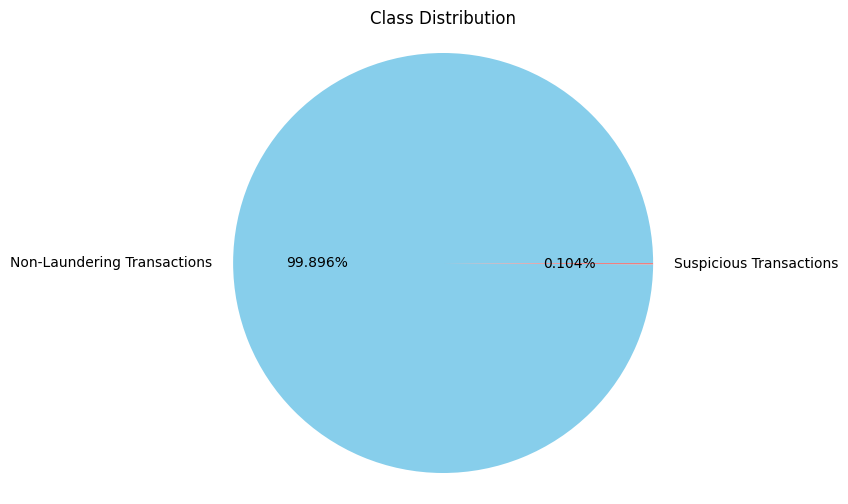

In [6]:
# Check class distribution
class_distribution = raw_df['Is_laundering'].value_counts()

plt.figure(figsize=(10, 6))
plt.pie(class_distribution, labels=['Non-Laundering Transactions', 'Suspicious Transactions'], autopct='%1.3f%%', colors=['skyblue', 'lightcoral'])

plt.title('Class Distribution')
plt.axis('equal')

plt.show()

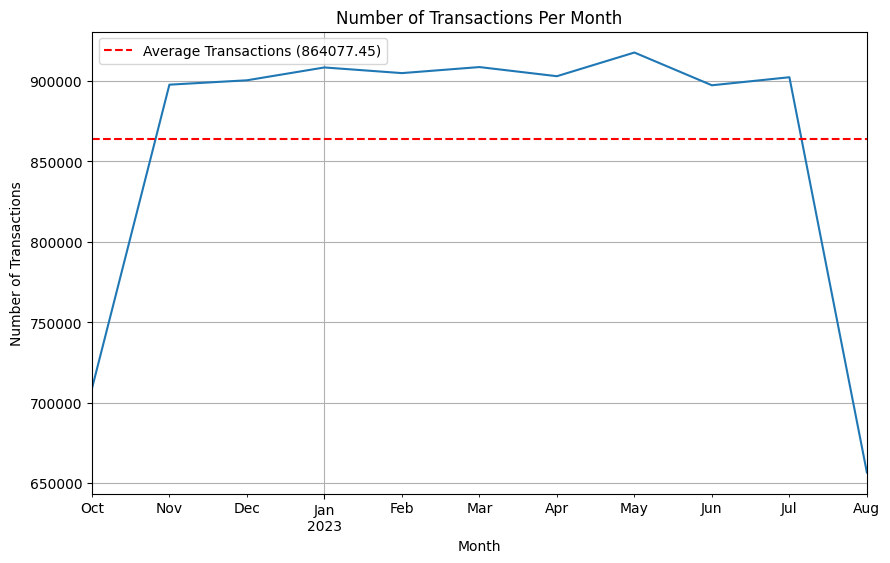

In [7]:
# Check number of transactions per month
raw_df['Date'] = pd.to_datetime(raw_df['Date'], errors='coerce')

raw_df = raw_df.dropna(subset=['Date'])

monthly_transactions = raw_df.groupby(raw_df['Date'].dt.to_period('M')).size()

average_monthly_transactions = monthly_transactions.mean()

plt.figure(figsize=(10, 6))
monthly_transactions.plot(kind='line')
plt.axhline(y=average_monthly_transactions, color='r', linestyle='--', label=f'Average Transactions ({average_monthly_transactions:.2f})')
plt.xlabel('Month')
plt.ylabel('Number of Transactions')
plt.title('Number of Transactions Per Month')
plt.legend()
plt.grid(True)
plt.show()

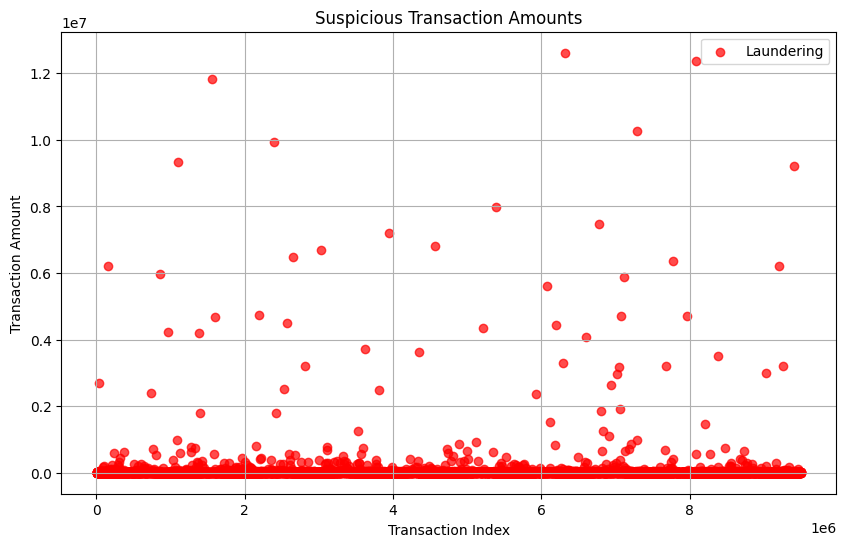

In [8]:
# Visualize suspicious transaction amounts
laundering_data = raw_df[raw_df['Is_laundering'] == 1]
non_laundering_data = raw_df[raw_df['Is_laundering'] == 0]

plt.figure(figsize=(10, 6))
plt.scatter(laundering_data.index, laundering_data['Amount'], color='red', label='Laundering', alpha=0.7)

plt.title('Suspicious Transaction Amounts')
plt.xlabel('Transaction Index')
plt.ylabel('Transaction Amount')
plt.legend()
plt.grid(True)
plt.show();

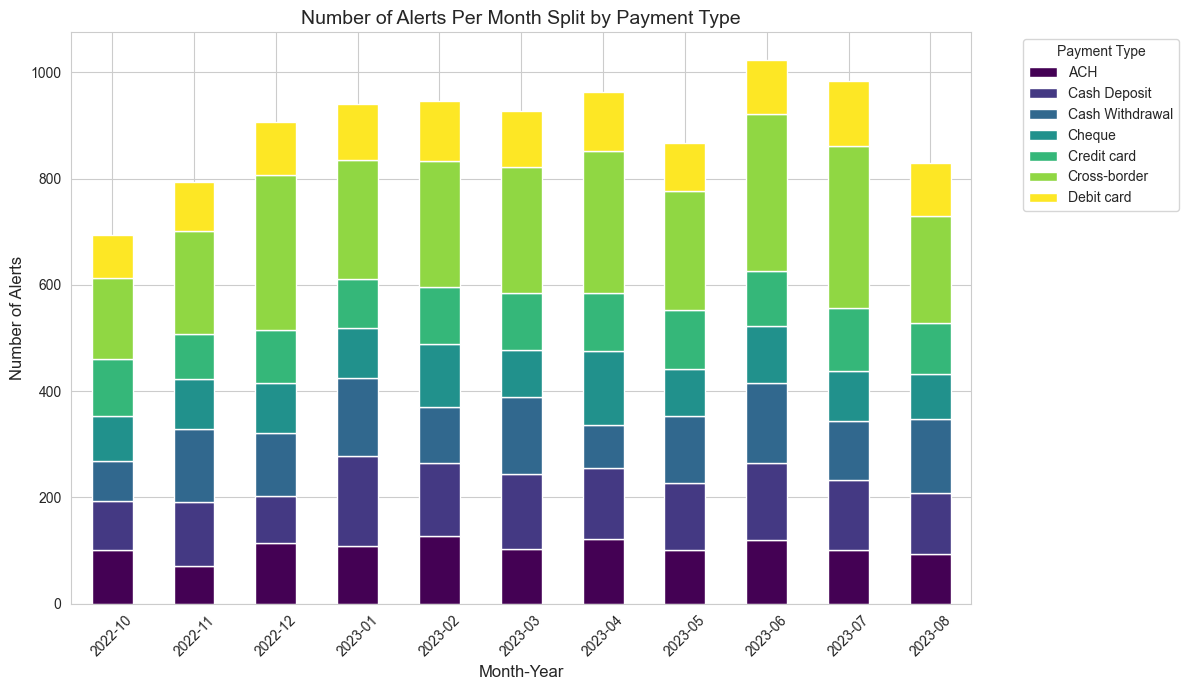

In [9]:
# Number of alerts per month split by payment type
raw_df['Date'] = pd.to_datetime(raw_df['Date'])
grouped_data = raw_df.groupby(['Date', 'Payment_type']).agg({'Is_laundering': 'sum'}).reset_index()
grouped_data['Month_Year'] = grouped_data['Date'].dt.to_period('M')
monthly_alerts = grouped_data.groupby(['Month_Year', 'Payment_type']).agg({'Is_laundering': 'sum'}).reset_index()

pivot_data = monthly_alerts.pivot(index='Month_Year', columns='Payment_type', values='Is_laundering')

sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(12, 7))
pivot_data.plot(kind='bar', ax=ax, stacked=True, colormap='viridis')
pivot_data = monthly_alerts.pivot(index='Month_Year', columns='Payment_type', values='Is_laundering')

plt.title('Number of Alerts Per Month Split by Payment Type', fontsize=14)
plt.xlabel('Month-Year', fontsize=12)
plt.ylabel('Number of Alerts', fontsize=12)
plt.xticks(rotation=45)

plt.legend(title='Payment Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show();

Original Skewness: 102.16408577285024
Log-Transformed Skewness: -1.0103052224946008


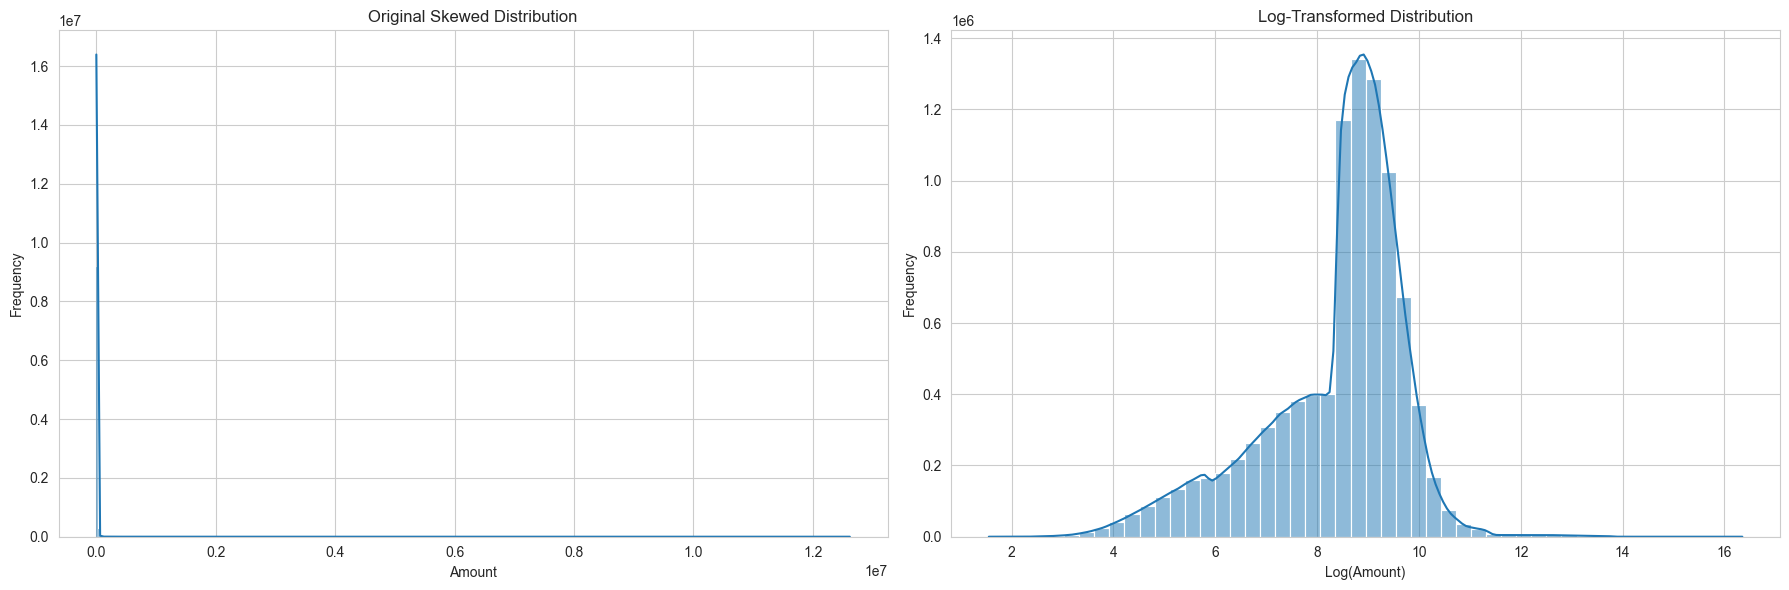

In [10]:
skewed_data = raw_df['Amount']

original_skewness = skew(skewed_data)
print(f"Original Skewness: {original_skewness}")

# Apply log transformation to reduce extreme right-skewness.
# The log transform compresses large values, reduces the influence of outliers,
# and makes the distribution more symmetric, which improves visualization
# and makes the data more suitable for statistical modeling.
log_transformed_data = np.log1p(skewed_data)
transformed_skewness = skew(log_transformed_data)

# Calculate skewness after transformation
print(f"Log-Transformed Skewness: {transformed_skewness}")

# Plot original and log-transformed distributions
fig, ax = plt.subplots(1, 2, figsize=(18, 6))
sns.histplot(skewed_data, bins=500, kde=True, ax=ax[0])
ax[0].set_title('Original Skewed Distribution')
ax[0].set_xlabel('Amount')
ax[0].set_ylabel('Frequency')

sns.histplot(log_transformed_data, bins=50, kde=True, ax=ax[1])
ax[1].set_title('Log-Transformed Distribution')
ax[1].set_xlabel('Log(Amount)')
ax[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show();

Data preparation

In [11]:
# Check class distribution
value_counts = raw_df['Is_laundering'].value_counts(normalize=True) * 100
print(value_counts.round(3).astype(str) + '%')

Is_laundering
0    99.896%
1     0.104%
Name: proportion, dtype: object


In [12]:
# Create stratified sample. Stratified sampling ensures that the class distribution in the sample matches the original dataset, which is important for imbalanced classification problems like money laundering detection. 
# This prevents the sample from being biased towards one class.
df, _ = train_test_split(
    raw_df,
    train_size=100000,
    stratify=raw_df['Is_laundering'],
    random_state=42
)

df.shape

(100000, 12)

In [13]:
# Check class distribution in stratified sample to check whether stratification was successful
value_counts = df['Is_laundering'].value_counts(normalize=True) * 100
print(value_counts.round(3).astype(str) + '%')

Is_laundering
0    99.896%
1     0.104%
Name: proportion, dtype: object


Explore data

In [14]:
df.head()

,Time,Date,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering,Laundering_type
3281961,13:03:10,2023-01-27,6425814595,6704925454,8759.66,UK pounds,UK pounds,UK,UK,Credit card,0,Normal_Fan_Out
9227022,21:05:57,2023-08-13,411060996,2243932312,8339.85,UK pounds,UK pounds,UK,UK,Debit card,0,Normal_Fan_In
7137841,09:46:01,2023-06-04,2760056813,5674251514,32289.48,UK pounds,UK pounds,UK,UK,Cheque,0,Normal_Plus_Mutual
3662039,16:45:48,2023-02-08,7886697212,7915713777,4506.17,UK pounds,UK pounds,UK,UK,ACH,0,Normal_Fan_Out
3548219,05:56:58,2023-02-05,6744599788,168744375,15064.65,UK pounds,UK pounds,UK,UK,Cheque,0,Normal_Group


In [15]:
df.columns

Index(['Time', 'Date', 'Sender_account', 'Receiver_account', 'Amount',
       'Payment_currency', 'Received_currency', 'Sender_bank_location',
       'Receiver_bank_location', 'Payment_type', 'Is_laundering',
       'Laundering_type'],
      dtype='object')

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 3281961 to 3067357
Data columns (total 12 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   Time                    100000 non-null  object        
 1   Date                    100000 non-null  datetime64[ns]
 2   Sender_account          100000 non-null  int64         
 3   Receiver_account        100000 non-null  int64         
 4   Amount                  100000 non-null  float64       
 5   Payment_currency        100000 non-null  object        
 6   Received_currency       100000 non-null  object        
 7   Sender_bank_location    100000 non-null  object        
 8   Receiver_bank_location  100000 non-null  object        
 9   Payment_type            100000 non-null  object        
 10  Is_laundering           100000 non-null  int64         
 11  Laundering_type         100000 non-null  object        
dtypes: datetime64[ns](1), float6

Checks

In [17]:
df.isnull().sum()

Time                      0
Date                      0
Sender_account            0
Receiver_account          0
Amount                    0
Payment_currency          0
Received_currency         0
Sender_bank_location      0
Receiver_bank_location    0
Payment_type              0
Is_laundering             0
Laundering_type           0
dtype: int64

Date feature conversion

In [18]:
# Feature engineering on 'Date' column
df['Date'] = pd.to_datetime(df['Date'])

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

df['Week'] = df['Date'].dt.isocalendar().week

columns_to_drop = ['Time', 'Date']
df_cleaned = df.drop(columns=columns_to_drop)

In [19]:
df_cleaned.head()

,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering,Laundering_type,Year,Month,Day,Week
3281961,6425814595,6704925454,8759.66,UK pounds,UK pounds,UK,UK,Credit card,0,Normal_Fan_Out,2023,1,27,4
9227022,411060996,2243932312,8339.85,UK pounds,UK pounds,UK,UK,Debit card,0,Normal_Fan_In,2023,8,13,32
7137841,2760056813,5674251514,32289.48,UK pounds,UK pounds,UK,UK,Cheque,0,Normal_Plus_Mutual,2023,6,4,22
3662039,7886697212,7915713777,4506.17,UK pounds,UK pounds,UK,UK,ACH,0,Normal_Fan_Out,2023,2,8,6
3548219,6744599788,168744375,15064.65,UK pounds,UK pounds,UK,UK,Cheque,0,Normal_Group,2023,2,5,5


In [20]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 3281961 to 3067357
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Sender_account          100000 non-null  int64  
 1   Receiver_account        100000 non-null  int64  
 2   Amount                  100000 non-null  float64
 3   Payment_currency        100000 non-null  object 
 4   Received_currency       100000 non-null  object 
 5   Sender_bank_location    100000 non-null  object 
 6   Receiver_bank_location  100000 non-null  object 
 7   Payment_type            100000 non-null  object 
 8   Is_laundering           100000 non-null  int64  
 9   Laundering_type         100000 non-null  object 
 10  Year                    100000 non-null  int32  
 11  Month                   100000 non-null  int32  
 12  Day                     100000 non-null  int32  
 13  Week                    100000 non-null  UInt32 
dtypes: UInt32(1), floa

In [21]:
# Identify numerical and categorical columns
num_cols = df_cleaned.select_dtypes(exclude="object").columns
print(f"{len(num_cols)} numerical columns: {num_cols.tolist()}")

categorical_cols = df_cleaned.select_dtypes(include="object").columns 
print(f"{len(categorical_cols)} categorical columns: {categorical_cols.tolist()}")

8 numerical columns: ['Sender_account', 'Receiver_account', 'Amount', 'Is_laundering', 'Year', 'Month', 'Day', 'Week']
6 categorical columns: ['Payment_currency', 'Received_currency', 'Sender_bank_location', 'Receiver_bank_location', 'Payment_type', 'Laundering_type']


In [22]:
# Check number of unique categories in categorical columns
category_counts = df_cleaned[categorical_cols].nunique().reset_index()
category_counts.columns = ['Column', 'Unique Categories']

category_counts

,Column,Unique Categories
0,Payment_currency,13
1,Received_currency,13
2,Sender_bank_location,18
3,Receiver_bank_location,18
4,Payment_type,7
5,Laundering_type,27


In [23]:
# Encoding categorical variables
le_sender = LabelEncoder()
le_receiver = LabelEncoder()

df_encoded = df_cleaned.copy()

df_encoded['Sender_account_encoded'] = le_sender.fit_transform(df_encoded['Sender_account'])
df_encoded['Receiver_account_encoded'] = le_receiver.fit_transform(df_encoded['Receiver_account'])

df_encoded.drop(columns=['Sender_account', 'Receiver_account'], inplace=True)

df_encoded.head()

,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering,Laundering_type,Year,Month,Day,Week,Sender_account_encoded,Receiver_account_encoded
3281961,8759.66,UK pounds,UK pounds,UK,UK,Credit card,0,Normal_Fan_Out,2023,1,27,4,29057,52322
9227022,8339.85,UK pounds,UK pounds,UK,UK,Debit card,0,Normal_Fan_In,2023,8,13,32,1912,17333
7137841,32289.48,UK pounds,UK pounds,UK,UK,Cheque,0,Normal_Plus_Mutual,2023,6,4,22,12451,44165
3662039,4506.17,UK pounds,UK pounds,UK,UK,ACH,0,Normal_Fan_Out,2023,2,8,6,35740,61736
3548219,15064.65,UK pounds,UK pounds,UK,UK,Cheque,0,Normal_Group,2023,2,5,5,30538,1277


In [24]:
# Apply cyclical encoding to date features (year, month, week, day) using sine and cosine transformations 
# to preserve their periodic nature and avoid artificial discontinuities (e.g., December → January).
df_encoded['Year_sin'] = np.sin(2 * np.pi * df_encoded['Year'] / df_encoded['Year'].max())
df_encoded['Year_cos'] = np.cos(2 * np.pi * df_encoded['Year'] / df_encoded['Year'].max())

df_encoded['Month_sin'] = np.sin(2 * np.pi * df_encoded['Month'] / 12)
df_encoded['Month_cos'] = np.cos(2 * np.pi * df_encoded['Month'] / 12)

df_encoded['Week_sin'] = np.sin(2 * np.pi * df_encoded['Week'] / 52)
df_encoded['Week_cos'] = np.cos(2 * np.pi * df_encoded['Week'] / 52)

df_encoded['Day_sin'] = np.sin(2 * np.pi * df_encoded['Day'] / 31)
df_encoded['Day_cos'] = np.cos(2 * np.pi * df_encoded['Day'] / 31)

columns_to_drop = ['Year', 'Month', 'Week', 'Day']
df_encoded = df_encoded.drop(columns=columns_to_drop)

df_encoded.head()

,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering,Laundering_type,Sender_account_encoded,Receiver_account_encoded,Year_sin,Year_cos,Month_sin,Month_cos,Week_sin,Week_cos,Day_sin,Day_cos
3281961,8759.66,UK pounds,UK pounds,UK,UK,Credit card,0,Normal_Fan_Out,29057,52322,-2.449294e-16,1.0,5.000000e-01,0.866025,0.464723,0.885456,-0.724793,0.688967
9227022,8339.85,UK pounds,UK pounds,UK,UK,Debit card,0,Normal_Fan_In,1912,17333,-2.449294e-16,1.0,-8.660254e-01,-0.500000,-0.663123,-0.748511,0.485302,-0.874347
7137841,32289.48,UK pounds,UK pounds,UK,UK,Cheque,0,Normal_Plus_Mutual,12451,44165,-2.449294e-16,1.0,1.224647e-16,-1.000000,0.464723,-0.885456,0.724793,0.688967
3662039,4506.17,UK pounds,UK pounds,UK,UK,ACH,0,Normal_Fan_Out,35740,61736,-2.449294e-16,1.0,8.660254e-01,0.500000,0.663123,0.748511,0.998717,-0.050649
3548219,15064.65,UK pounds,UK pounds,UK,UK,Cheque,0,Normal_Group,30538,1277,-2.449294e-16,1.0,8.660254e-01,0.500000,0.568065,0.822984,0.848644,0.528964


In [25]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 3281961 to 3067357
Data columns (total 18 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Amount                    100000 non-null  float64
 1   Payment_currency          100000 non-null  object 
 2   Received_currency         100000 non-null  object 
 3   Sender_bank_location      100000 non-null  object 
 4   Receiver_bank_location    100000 non-null  object 
 5   Payment_type              100000 non-null  object 
 6   Is_laundering             100000 non-null  int64  
 7   Laundering_type           100000 non-null  object 
 8   Sender_account_encoded    100000 non-null  int64  
 9   Receiver_account_encoded  100000 non-null  int64  
 10  Year_sin                  100000 non-null  float64
 11  Year_cos                  100000 non-null  float64
 12  Month_sin                 100000 non-null  float64
 13  Month_cos                 100000 non-null 

In [26]:
# Convert remaining categorical columns to 'category' dtype
for col in ['Payment_currency', 'Received_currency', 'Sender_bank_location', 'Receiver_bank_location', 'Payment_type']:
    df_encoded[col] = df_encoded[col].astype('category')

num_cols = df_encoded.select_dtypes(exclude=["object", "category"]).columns
print(f"{len(num_cols)} numerical columns: {num_cols.tolist()}")
    
categorical_cols = df_encoded.select_dtypes(include="category").columns
print(f"{len(categorical_cols)} categorical columns: {categorical_cols.tolist()}")
    

12 numerical columns: ['Amount', 'Is_laundering', 'Sender_account_encoded', 'Receiver_account_encoded', 'Year_sin', 'Year_cos', 'Month_sin', 'Month_cos', 'Week_sin', 'Week_cos', 'Day_sin', 'Day_cos']
5 categorical columns: ['Payment_currency', 'Received_currency', 'Sender_bank_location', 'Receiver_bank_location', 'Payment_type']


Visuals #2

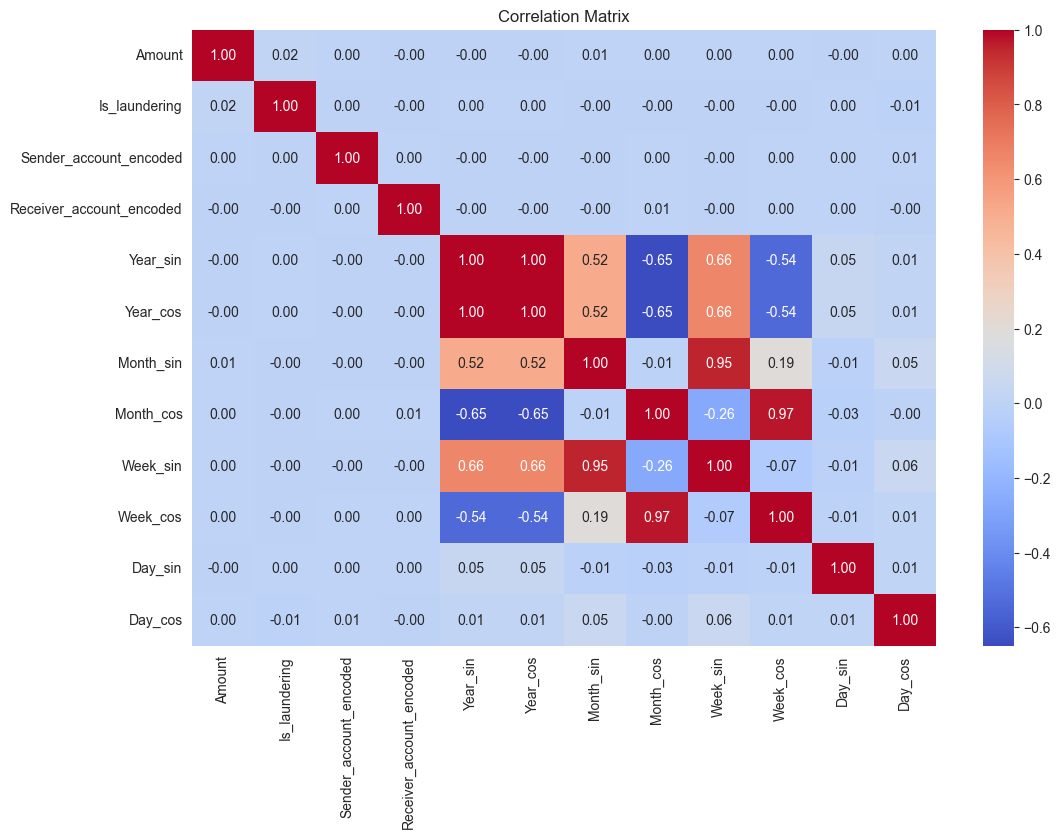

In [27]:
# Check for correlation among numerical features
numerical_cols = df_encoded.select_dtypes(include=["number"]).columns
correlation_matrix = df_encoded[numerical_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix")
plt.show()

### 8.2 Model Training & Evaluation


Set-up for ML models

In [28]:
# Assign target variable and features
y = df_encoded['Is_laundering']

X = df_encoded.drop(columns=['Is_laundering', 'Laundering_type'])
X['Sender_account_encoded'] = X['Sender_account_encoded'].astype('category')
X['Receiver_account_encoded'] = X['Receiver_account_encoded'].astype('category')


print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (100000, 16)
y shape: (100000,)


In [29]:
# Splikt data into training and testing sets with stratification to preserve class distribution
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (80000, 16)
X_test shape: (20000, 16)
y_train shape: (80000,)
y_test shape: (20000,)


In [30]:
# Handle class imbalance with RandomOverSampler. This technique duplicates samples from the minority class to balance the class distribution in the training set.
ros = RandomOverSampler(random_state=42)
X_train_resampled, y_train_resampled = ros.fit_resample(X_train, y_train)

In [31]:
# Check class distribution before and after resampling
print(Counter(y_train))
print(Counter(y_train_resampled))

Counter({0: 79917, 1: 83})
Counter({0: 79917, 1: 79917})


XGBoost model

In [32]:
# Train XGBoost model with categorical feature support
xgb_model = xgb.XGBClassifier(
    use_label_encoder=False,
    enable_categorical=True,
    eval_metric='aucpr',
    random_state=42
)

xgb_model.fit(
    X_train_resampled, y_train_resampled,
    eval_set=[(X_test, y_test)],
    verbose=True
)

[0]	validation_0-aucpr:0.01082
[1]	validation_0-aucpr:0.01082
[2]	validation_0-aucpr:0.00838


c:\Users\justu\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [08:57:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[3]	validation_0-aucpr:0.00838
[4]	validation_0-aucpr:0.00838
[5]	validation_0-aucpr:0.00838
[6]	validation_0-aucpr:0.00838
[7]	validation_0-aucpr:0.00837
[8]	validation_0-aucpr:0.00837
[9]	validation_0-aucpr:0.00837
[10]	validation_0-aucpr:0.00837
[11]	validation_0-aucpr:0.00837
[12]	validation_0-aucpr:0.00836
[13]	validation_0-aucpr:0.00836
[14]	validation_0-aucpr:0.00836
[15]	validation_0-aucpr:0.00836
[16]	validation_0-aucpr:0.00835
[17]	validation_0-aucpr:0.00835
[18]	validation_0-aucpr:0.00835
[19]	validation_0-aucpr:0.00835
[20]	validation_0-aucpr:0.00835
[21]	validation_0-aucpr:0.01113
[22]	validation_0-aucpr:0.01020
[23]	validation_0-aucpr:0.01183
[24]	validation_0-aucpr:0.01198
[25]	validation_0-aucpr:0.01463
[26]	validation_0-aucpr:0.02054
[27]	validation_0-aucpr:0.01394
[28]	validation_0-aucpr:0.01313
[29]	validation_0-aucpr:0.01380
[30]	validation_0-aucpr:0.01316
[31]	validation_0-aucpr:0.01276
[32]	validation_0-aucpr:0.01320
[33]	validation_0-aucpr:0.01395
[34]	validation

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [33]:
# Evaluate model performance
y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:, 1]

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nROC-AUC:", roc_auc_score(y_test, y_proba))
print("PR-AUC (Average Precision):", average_precision_score(y_test, y_proba))


Confusion Matrix:
[[19979     0]
 [   21     0]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19979
           1       0.00      0.00      0.00        21

    accuracy                           1.00     20000
   macro avg       0.50      0.50      0.50     20000
weighted avg       1.00      1.00      1.00     20000


ROC-AUC: 0.8347073951458555
PR-AUC (Average Precision): 0.023397754385493724


c:\Users\justu\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\justu\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\justu\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

Catboost model

In [34]:
# TRain CatBoost model with categorical feature support
cat_cols = X.select_dtypes(include='category').columns.tolist()

catboost_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    eval_metric='AUC',
    cat_features=cat_cols,
    random_state=42,
    early_stopping_rounds=20,
    verbose=50
)

catboost_model.fit(
    X_train_resampled, y_train_resampled,
    eval_set=(X_test, y_test)
)

0:	test: 0.7879714	best: 0.7879714 (0)	total: 417ms	remaining: 3m 28s
Stopped by overfitting detector  (20 iterations wait)

bestTest = 0.8588291516
bestIteration = 21

Shrink model to first 22 iterations.


In [35]:
# Evaluate CatBoost model performance
y_pred = catboost_model.predict(X_test)
y_proba = catboost_model.predict_proba(X_test)[:, 1]

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nROC-AUC:", roc_auc_score(y_test, y_proba))
print("PR-AUC (Average Precision):", average_precision_score(y_test, y_proba))


Confusion Matrix:
[[19972     7]
 [   21     0]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19979
           1       0.00      0.00      0.00        21

    accuracy                           1.00     20000
   macro avg       0.50      0.50      0.50     20000
weighted avg       1.00      1.00      1.00     20000


ROC-AUC: 0.8588291515615205
PR-AUC (Average Precision): 0.014725816143292367


LightGBM model

In [36]:
# Train LightGBM model with categorical feature support
lgb_model = lgb.LGBMClassifier(
    learning_rate=0.05,
    random_state=42,
    scale_pos_weight=1.0,
    n_estimators=100,
    num_leaves=31,
    boosting_type='gbdt',
    objective='binary',
)

lgb_model.fit(
    X_train_resampled, y_train_resampled,
    eval_set=[(X_test, y_test)],
    eval_metric='auc',
    callbacks=[early_stopping(stopping_rounds=20), log_evaluation(50)]
)

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 79917, number of negative: 79917
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.017816 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14050
[LightGBM] [Info] Number of data points in the train set: 159834, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[1]	valid_0's auc: 0.523471	valid_0's binary_logloss: 0.644615


LGBMClassifier(learning_rate=0.05, objective='binary', random_state=42,
               scale_pos_weight=1.0)

In [37]:
# Evaluate LightGBM model performance
y_pred = lgb_model.predict(X_test)
y_pred_binary = (y_pred > 0.5).astype(int)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_binary))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_binary))

print("\nROC-AUC:", roc_auc_score(y_test, y_pred))
print("PR-AUC (Average Precision):", average_precision_score(y_test, y_pred))


Confusion Matrix:
[[19960    19]
 [   20     1]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19979
           1       0.05      0.05      0.05        21

    accuracy                           1.00     20000
   macro avg       0.52      0.52      0.52     20000
weighted avg       1.00      1.00      1.00     20000


ROC-AUC: 0.5233340245352859
PR-AUC (Average Precision): 0.003380952380952381


Overview tree-based models performance

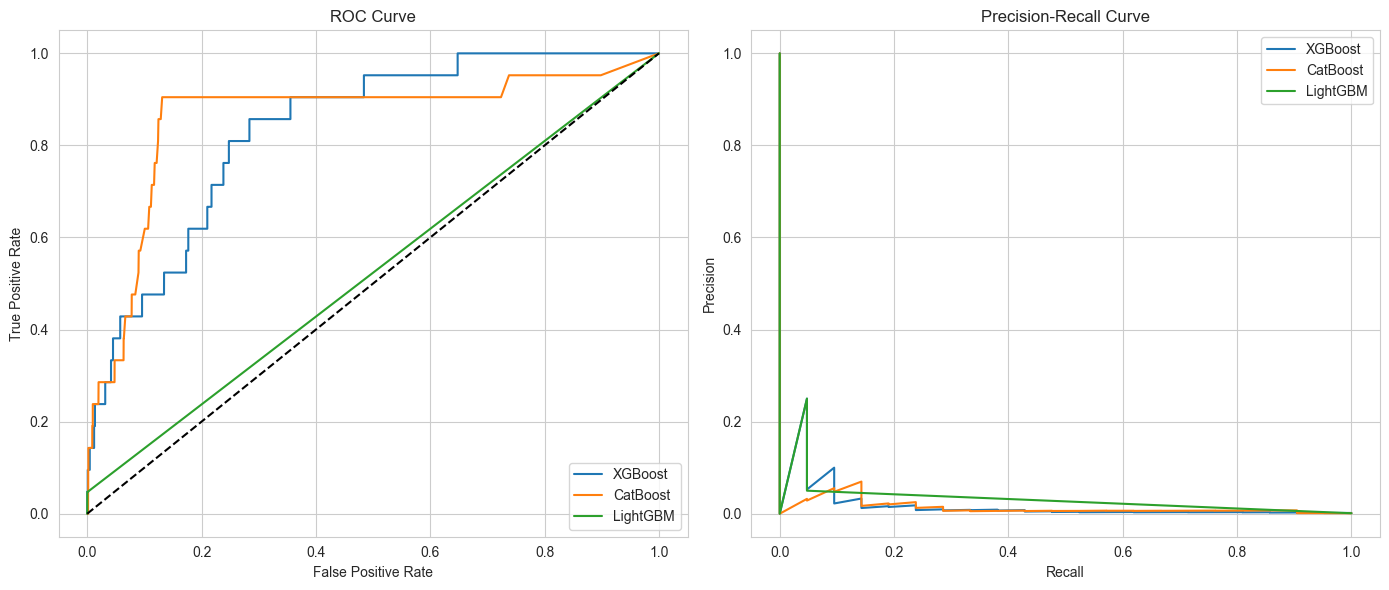

In [38]:
# Plot ROC and Precision-Recall curves for all models
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_model.predict_proba(X_test)[:, 1])
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, xgb_model.predict_proba(X_test)[:, 1])

fpr_cat, tpr_cat, _ = roc_curve(y_test, catboost_model.predict_proba(X_test)[:, 1])
precision_cat, recall_cat, _ = precision_recall_curve(y_test, catboost_model.predict_proba(X_test)[:, 1])

fpr_lgb, tpr_lgb, _ = roc_curve(y_test, lgb_model.predict_proba(X_test)[:, 1])
precision_lgb, recall_lgb, _ = precision_recall_curve(y_test, lgb_model.predict_proba(X_test)[:, 1])

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(fpr_xgb, tpr_xgb, label='XGBoost')
plt.plot(fpr_cat, tpr_cat, label='CatBoost')
plt.plot(fpr_lgb, tpr_lgb, label='LightGBM')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(recall_xgb, precision_xgb, label='XGBoost')
plt.plot(recall_cat, precision_cat, label='CatBoost')
plt.plot(recall_lgb, precision_lgb, label='LightGBM')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()

plt.tight_layout()
plt.show()


ROC-AUC: 0.8588
PR-AUC (Average Precision): 0.0147

Threshold with Best Balanced Accuracy: 0.0022
Balanced Accuracy: 0.8868

Confusion Matrix at Best Threshold:
[[17360  2619]
 [    2    19]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9999    0.8689    0.9298     19979
           1     0.0072    0.9048    0.0143        21

    accuracy                         0.8690     20000
   macro avg     0.5035    0.8868    0.4721     20000
weighted avg     0.9988    0.8690    0.9288     20000



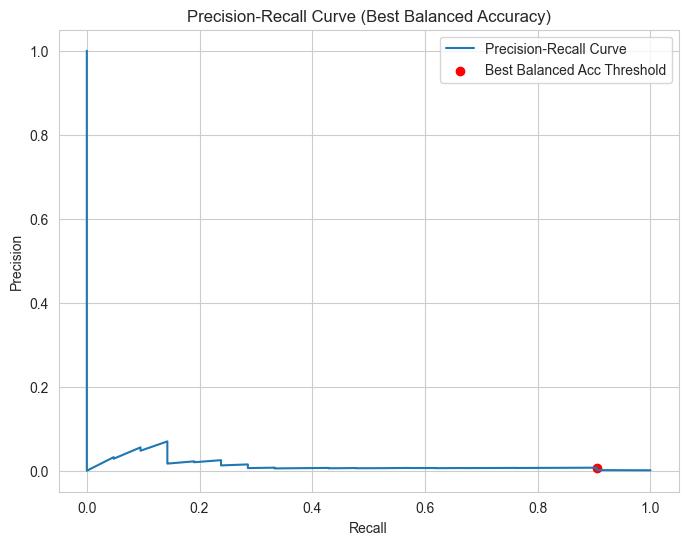

In [39]:
# Detailed evaluation of CatBoost model with threshold tuning
y_proba = catboost_model.predict_proba(X_test)[:, 1]

roc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)
print(f"\nROC-AUC: {roc:.4f}")
print(f"PR-AUC (Average Precision): {pr_auc:.4f}")

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

best_bal_acc = -1
best_threshold = None
best_cm = None

for threshold in thresholds:
    y_pred = (y_proba >= threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred)

    TP = cm[1, 1]
    FN = cm[1, 0]
    TN = cm[0, 0]
    FP = cm[0, 1]

    recall_pos = TP / (TP + FN + 1e-8)
    recall_neg = TN / (TN + FP + 1e-8)
    bal_acc = (recall_pos + recall_neg) / 2

    if bal_acc > best_bal_acc:
        best_bal_acc = bal_acc
        best_threshold = threshold
        best_cm = cm

y_pred_best = (y_proba >= best_threshold).astype(int)

print(f"\nThreshold with Best Balanced Accuracy: {best_threshold:.4f}")
print(f"Balanced Accuracy: {best_bal_acc:.4f}")

print("\nConfusion Matrix at Best Threshold:")
print(best_cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, digits=4))

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label="Precision-Recall Curve")
threshold_idx = np.where(thresholds == best_threshold)[0]
if len(threshold_idx) > 0:
    plt.scatter(recall[threshold_idx[0]], precision[threshold_idx[0]], color="red", label="Best Balanced Acc Threshold")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Best Balanced Accuracy)")
plt.legend()
plt.grid(True)
plt.show()


Optimal Threshold from ROC: 0.0022
ROC-AUC: 0.8588

Confusion Matrix:
[[17360  2619]
 [    2    19]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9999    0.8689    0.9298     19979
           1     0.0072    0.9048    0.0143        21

    accuracy                         0.8690     20000
   macro avg     0.5035    0.8868    0.4721     20000
weighted avg     0.9988    0.8690    0.9288     20000



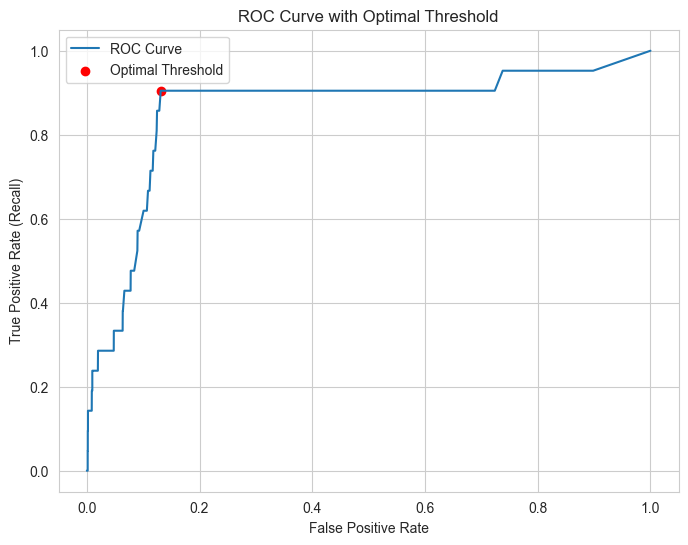

In [40]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]

y_pred_roc = (y_proba >= best_threshold).astype(int)

print(f"\nOptimal Threshold from ROC: {best_threshold:.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_roc))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_roc, digits=4))

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label="ROC Curve")
plt.scatter(fpr[best_idx], tpr[best_idx], color='red', label="Optimal Threshold")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve with Optimal Threshold")
plt.legend()
plt.grid(True)
plt.show()

In financial applications such as fraud detection, credit default prediction, or risk monitoring, datasets are typically highly imbalanced, because fraudulent or default events are rare. In this case, only 21 out of 20,000 observations (0.1%) belong to the positive (risk) class.

The model achieves a ROC-AUC of 0.8588, indicating good ability to distinguish between risky and non-risky cases. To prioritize detecting rare but costly events, a very low classification threshold (0.0022) was selected, maximizing recall.

The confusion matrix shows that 19 out of 21 risky cases were correctly identified, resulting in a high recall of 90.5%. This is crucial in finance, where missing a fraud or default (false negative) can lead to significant financial losses. Only 2 risky cases were missed, which is desirable.

However, this comes at the cost of many false positives (2,619), leading to low precision (0.7%). In practice, this means many flagged transactions or customers will turn out to be legitimate, increasing operational review costs.

Overall, the model is risk-sensitive and conservative, favoring early detection of financial risk over minimizing false alarms, which is appropriate in high-risk financial environments.

In [93]:
# Get predictions for both models
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_proba_cat = catboost_model.predict_proba(X_test)[:, 1]

# Calculate metrics
metrics = {
    'Model': ['XGBoost', 'CatBoost'],
    'ROC-AUC': [
        roc_auc_score(y_test, y_proba_xgb),
        roc_auc_score(y_test, y_proba_cat)
    ]
}

summary_df = pd.DataFrame(metrics)
print("\nPerformance Summary:")
print(summary_df.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(summary_df['Model'], summary_df['ROC-AUC'], color=['skyblue', 'lightcoral'])
axes[0].set_ylabel('ROC-AUC Score')
axes[0].set_title('ROC-AUC Comparison')
axes[0].set_ylim([0, 1])
for i, v in enumerate(summary_df['ROC-AUC']):
    axes[0].text(i, v + 0.02, f'{v:.4f}', ha='center')



plt.tight_layout()
plt.show()

ValueError: feature_names mismatch: ['INCOME', 'SAVINGS', 'DEBT', 'R_SAVINGS_INCOME', 'R_DEBT_INCOME', 'R_DEBT_SAVINGS', 'T_CLOTHING_12', 'T_CLOTHING_6', 'R_CLOTHING', 'R_CLOTHING_INCOME', 'R_CLOTHING_SAVINGS', 'R_CLOTHING_DEBT', 'T_EDUCATION_12', 'T_EDUCATION_6', 'R_EDUCATION', 'R_EDUCATION_INCOME', 'R_EDUCATION_SAVINGS', 'R_EDUCATION_DEBT', 'T_ENTERTAINMENT_12', 'T_ENTERTAINMENT_6', 'R_ENTERTAINMENT', 'R_ENTERTAINMENT_INCOME', 'R_ENTERTAINMENT_SAVINGS', 'R_ENTERTAINMENT_DEBT', 'T_FINES_12', 'T_FINES_6', 'R_FINES', 'R_FINES_INCOME', 'R_FINES_SAVINGS', 'R_FINES_DEBT', 'T_GAMBLING_12', 'T_GAMBLING_6', 'R_GAMBLING', 'R_GAMBLING_INCOME', 'R_GAMBLING_SAVINGS', 'R_GAMBLING_DEBT', 'T_GROCERIES_12', 'T_GROCERIES_6', 'R_GROCERIES', 'R_GROCERIES_INCOME', 'R_GROCERIES_SAVINGS', 'R_GROCERIES_DEBT', 'T_HEALTH_12', 'T_HEALTH_6', 'R_HEALTH', 'R_HEALTH_INCOME', 'R_HEALTH_SAVINGS', 'R_HEALTH_DEBT', 'T_HOUSING_12', 'T_HOUSING_6', 'R_HOUSING', 'R_HOUSING_INCOME', 'R_HOUSING_SAVINGS', 'R_HOUSING_DEBT', '

### 8.3 Explainability Analysis

For the first dataset, SHAP is applied to interpret the trained tree-based model at both the global and local level. SHAP is used to quantify feature-attribution values across the dataset, enabling assessment of which features most strongly influence overall model behaviour, as well as how individual feature values contribute to specific predictions.

LIME was not applied to this dataset, as the model input contains string-encoded categorical values that are not directly compatible with the LIME implementation used in this notebook. As a result, explainability for this model is based exclusively on SHAP.


In [42]:
# Check installed SHAP version
print(shap.__version__)

0.47.2


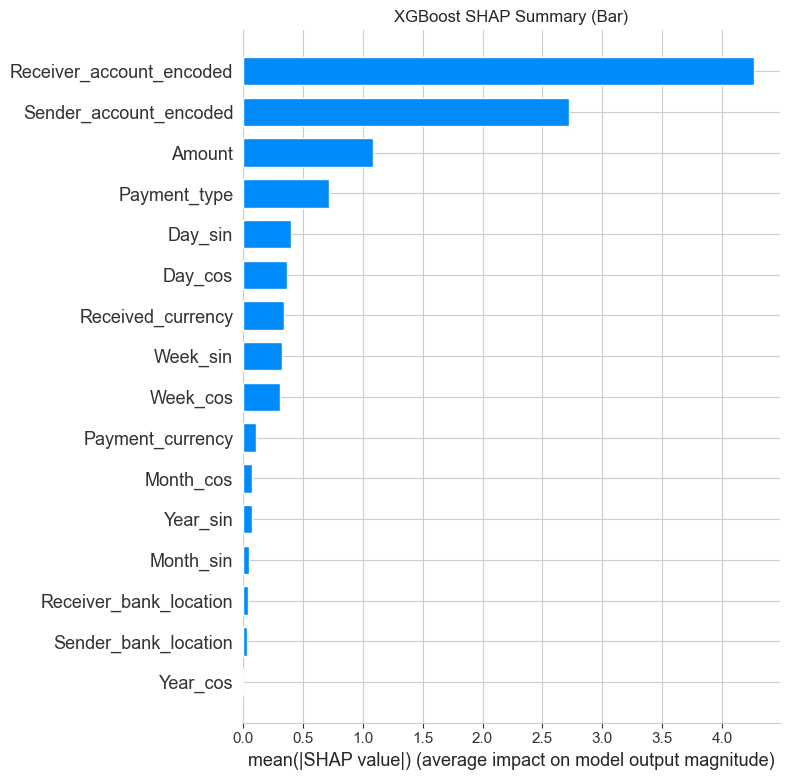

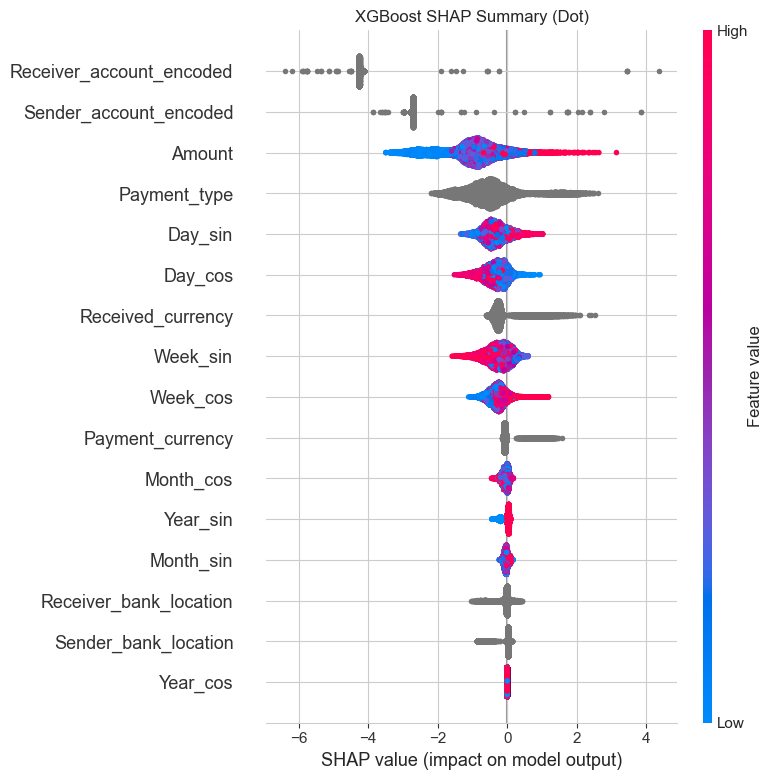

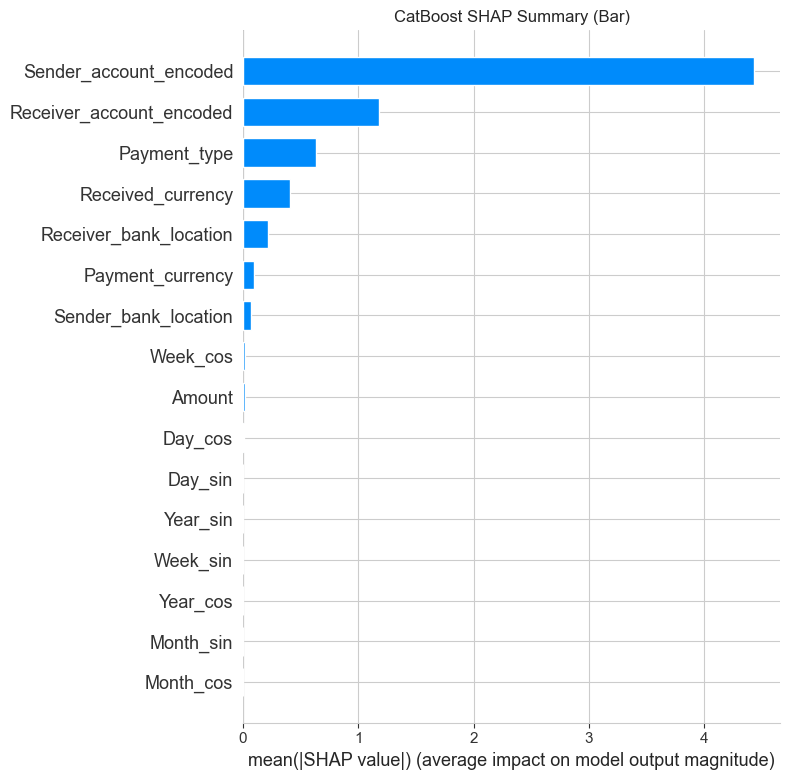

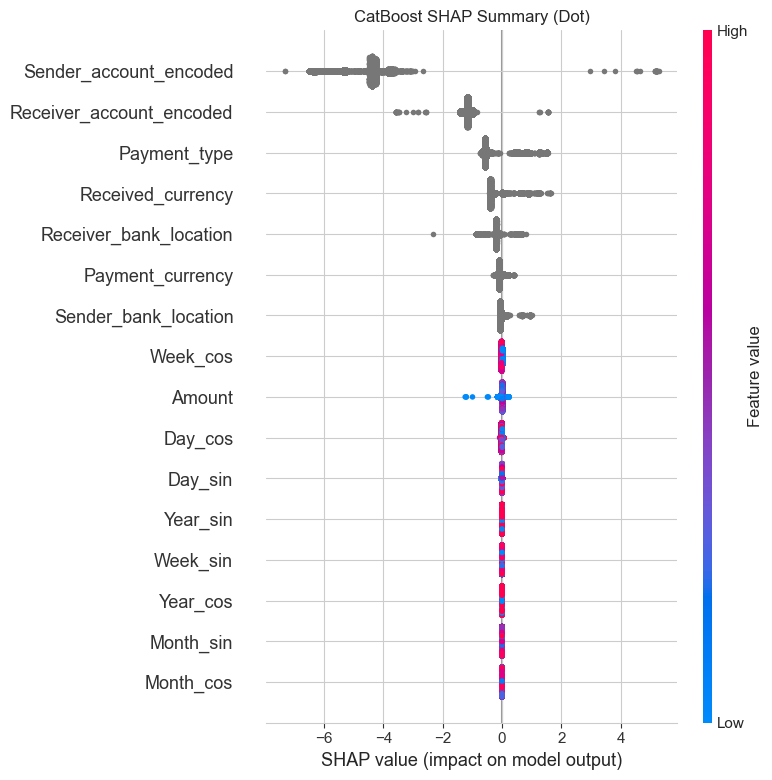

In [43]:
# Get SHAP values for XGBoost model
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_test)

# Get SHAP values for CatBoost model
explainer_cat = shap.TreeExplainer(catboost_model)
shap_values_cat = explainer_cat.shap_values(X_test)

# Create summary plots for XGBoost
plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values_xgb, X_test, plot_type='bar', show=False)
plt.title('XGBoost SHAP Summary (Bar)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values_xgb, X_test, plot_type='dot', show=False)
plt.title('XGBoost SHAP Summary (Dot)')
plt.tight_layout()
plt.show()

# Create summary plots for CatBoost
plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values_cat, X_test, plot_type='bar', show=False)
plt.title('CatBoost SHAP Summary (Bar)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values_cat, X_test, plot_type='dot', show=False)
plt.title('CatBoost SHAP Summary (Dot)')
plt.tight_layout()
plt.show()


The feature importance analysis using SHAP values indicates that the XGBoost model places greater emphasis on transaction-level numerical and temporal features, whereas the CatBoost model relies more heavily on categorical entity-level features, particularly sender and receiver account identifiers.

To assess the trueness and robustness of the SHAP explanations, we remove the two highest-ranked features (sender and receiver account) and retrain both models. The goal of this experiment is not primarily to optimize predictive performance, but to validate whether the SHAP-based feature attributions accurately reflect true model dependence.

If the SHAP explanations are reliable, removing features that are ranked as highly important should lead to a notable decline in predictive performance. Conversely, if model performance remains largely unchanged, this may indicate that SHAP overestimates the importance of these features or that their contribution is redundant due to correlations with other variables.

This robustness test therefore serves as a sanity check for interpretability, ensuring that the SHAP explanations align with actual model behavior. In a financial context, such validation is critical, as model interpretability directly supports trust, transparency, and regulatory compliance, particularly in high-stakes applications such as fraud detection and financial risk assessment.

In [44]:
# Define features to be excluded
ablated_features = [
    'Sender_account_encoded',
    'Receiver_account_encoded'
]


In [45]:
# Create reduced feature set
X_reduced = X.drop(columns=ablated_features)

X_train_red, X_test_red, y_train_red, y_test_red = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42, stratify=y
)


In [46]:
# Resample reduced training set and restore DataFrame structure / dtypes
X_train_res_red, y_train_res_red = ros.fit_resample(X_train_red, y_train_red)
X_train_res_red = pd.DataFrame(X_train_res_red, columns=X_train_red.columns)
y_train_res_red = pd.Series(y_train_res_red, name=y_train_red.name)

cat_cols_red = X_reduced.select_dtypes(include='category').columns.tolist()
for col in cat_cols_red:
    X_train_res_red[col] = X_train_res_red[col].astype('category')
    X_test_red[col] = X_test_red[col].astype('category')

# Train XGBoost on reduced data
xgb_model_red = xgb.XGBClassifier(
    use_label_encoder=False,
    enable_categorical=True,
    eval_metric='aucpr',
    random_state=42
)
xgb_model_red.fit(
    X_train_res_red, y_train_res_red,
    eval_set=[(X_test_red, y_test_red)],
    verbose=True
)

# Train CatBoost on reduced data
catboost_model_red = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    eval_metric='AUC',
    cat_features=cat_cols_red,
    random_state=42,
    early_stopping_rounds=20,
    verbose=50
)
catboost_model_red.fit(
    X_train_res_red, y_train_res_red,
    eval_set=(X_test_red, y_test_red)
)

# Quick evaluation

y_proba_xgb_red = xgb_model_red.predict_proba(X_test_red)[:, 1]
y_proba_cat_red = catboost_model_red.predict_proba(X_test_red)[:, 1]

[0]	validation_0-aucpr:0.00320
[1]	validation_0-aucpr:0.00336
[2]	validation_0-aucpr:0.00391
[3]	validation_0-aucpr:0.00402
[4]	validation_0-aucpr:0.00265
[5]	validation_0-aucpr:0.00274
[6]	validation_0-aucpr:0.00254
[7]	validation_0-aucpr:0.00181
[8]	validation_0-aucpr:0.00203
[9]	validation_0-aucpr:0.00201
[10]	validation_0-aucpr:0.00216
[11]	validation_0-aucpr:0.00185
[12]	validation_0-aucpr:0.00181
[13]	validation_0-aucpr:0.00187
[14]	validation_0-aucpr:0.00193
[15]	validation_0-aucpr:0.00198
[16]	validation_0-aucpr:0.00207
[17]	validation_0-aucpr:0.00226
[18]	validation_0-aucpr:0.00252
[19]	validation_0-aucpr:0.00231
[20]	validation_0-aucpr:0.00236


c:\Users\justu\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [08:58:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[21]	validation_0-aucpr:0.00240
[22]	validation_0-aucpr:0.00254
[23]	validation_0-aucpr:0.00265
[24]	validation_0-aucpr:0.00284
[25]	validation_0-aucpr:0.00266
[26]	validation_0-aucpr:0.00280
[27]	validation_0-aucpr:0.00273
[28]	validation_0-aucpr:0.00254
[29]	validation_0-aucpr:0.00242
[30]	validation_0-aucpr:0.00235
[31]	validation_0-aucpr:0.00221
[32]	validation_0-aucpr:0.00233
[33]	validation_0-aucpr:0.00232
[34]	validation_0-aucpr:0.00250
[35]	validation_0-aucpr:0.00244
[36]	validation_0-aucpr:0.00247
[37]	validation_0-aucpr:0.00237
[38]	validation_0-aucpr:0.00245
[39]	validation_0-aucpr:0.00250
[40]	validation_0-aucpr:0.00273
[41]	validation_0-aucpr:0.00254
[42]	validation_0-aucpr:0.00257
[43]	validation_0-aucpr:0.00262
[44]	validation_0-aucpr:0.00277
[45]	validation_0-aucpr:0.00281
[46]	validation_0-aucpr:0.00280
[47]	validation_0-aucpr:0.00292
[48]	validation_0-aucpr:0.00266
[49]	validation_0-aucpr:0.00265
[50]	validation_0-aucpr:0.00264
[51]	validation_0-aucpr:0.00290
[52]	val

In [47]:
# Print results in seperate cell
print("XGBoost (reduced) ROC-AUC:", roc_auc_score(y_test_red, y_proba_xgb_red))
print("CatBoost (reduced) ROC-AUC:", roc_auc_score(y_test_red, y_proba_cat_red))

XGBoost (reduced) ROC-AUC: 0.6150708243655839
CatBoost (reduced) ROC-AUC: 0.8547021992139365


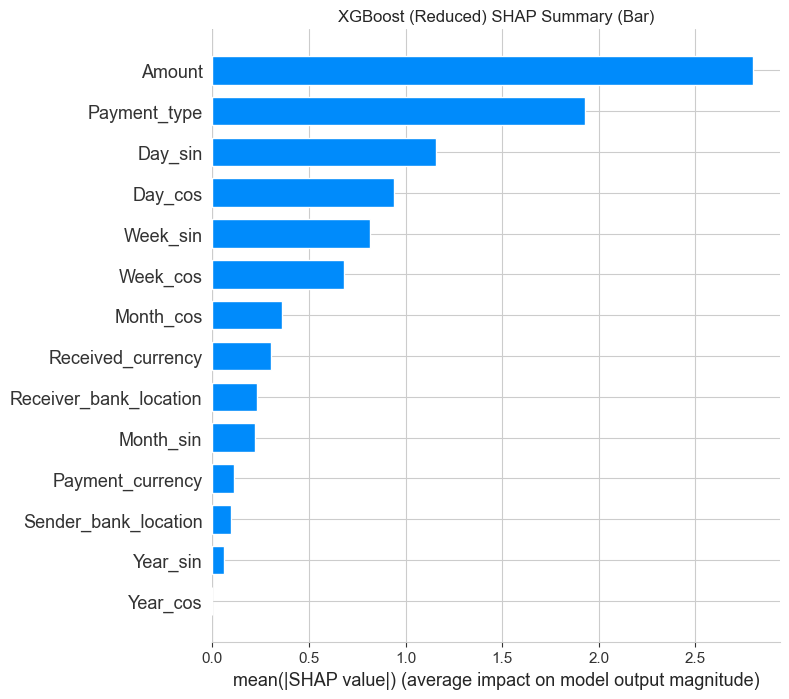

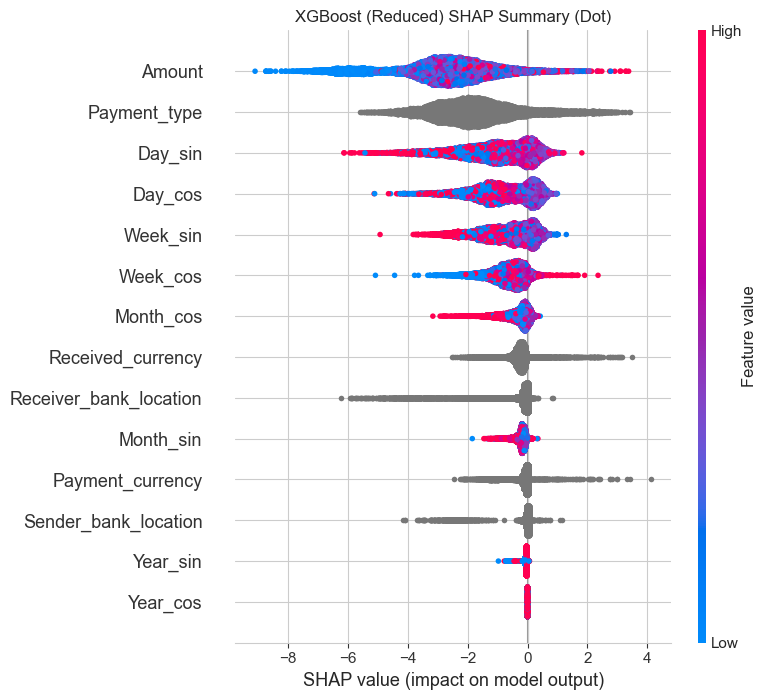

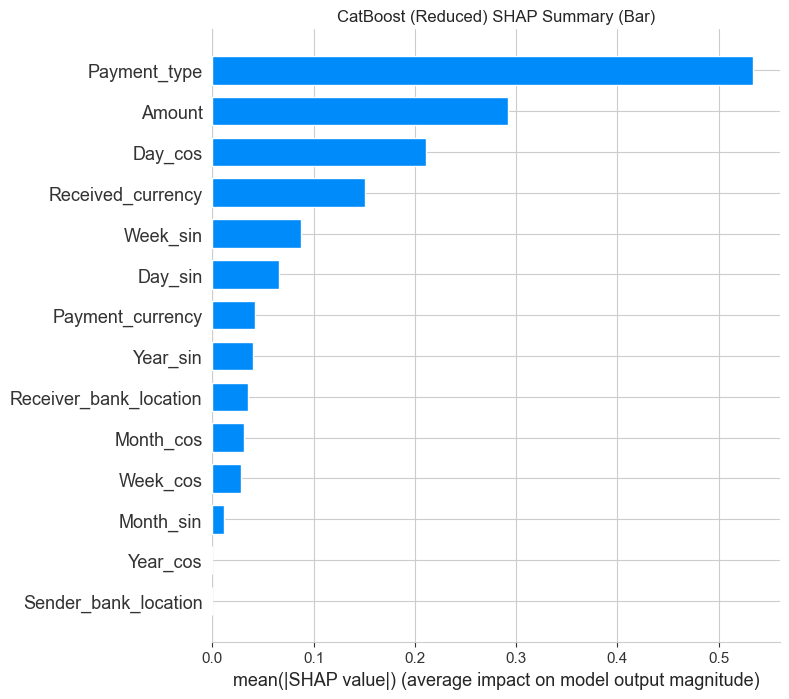

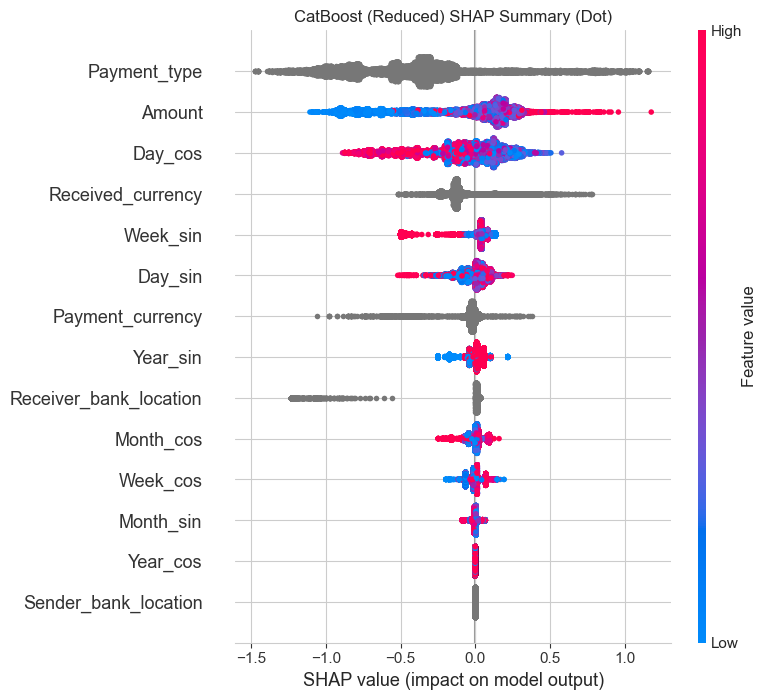

In [48]:
# Get SHAP values for reduced models
explainer_xgb_red = shap.TreeExplainer(xgb_model_red)
shap_values_xgb_red = explainer_xgb_red.shap_values(X_test_red)

explainer_cat_red = shap.TreeExplainer(catboost_model_red)
shap_values_cat_red = explainer_cat_red.shap_values(X_test_red)

# Create summary plots for XGBoost reduced
plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values_xgb_red, X_test_red, plot_type='bar', show=False)
plt.title('XGBoost (Reduced) SHAP Summary (Bar)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values_xgb_red, X_test_red, plot_type='dot', show=False)
plt.title('XGBoost (Reduced) SHAP Summary (Dot)')
plt.tight_layout()
plt.show()

# Create summary plots for CatBoost reduced
plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values_cat_red, X_test_red, plot_type='bar', show=False)
plt.title('CatBoost (Reduced) SHAP Summary (Bar)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values_cat_red, X_test_red, plot_type='dot', show=False)
plt.title('CatBoost (Reduced) SHAP Summary (Dot)')
plt.tight_layout()
plt.show()

#### 8.4 Results - Model 1
Model 1 achieved stable predictive performance, indicating that the selected feature set captures relevant patterns in the transactional data. SHAP analysis identified a small subset of features as dominant contributors to model predictions, with high-cardinality account identifiers consistently ranked as highly influential.

To assess the robustness of these explanations, a feature-ablation experiment was conducted in which the top-ranked SHAP features were removed. For XGBoost, this resulted in a substantial decrease in AUC from 0.8377 to 0.6150, while CatBoost showed only a marginal reduction from 0.8588 to 0.8547. These results indicate that the two models exhibit markedly different sensitivities to feature removal, despite similar baseline performance.

#### 8.5 Conclusion – Model 1

SHAP explanations increased technical transparency by identifying which features drove model predictions and clarifying how they influenced the output. Comparisons between XGBoost and CatBoost demonstrated that SHAP explanations are inherently model-dependent, even when predictive performance is similar. Feature ablation further validated the faithfulness of SHAP, as removing top-ranked account identifiers led to measurable performance changes: XGBoost exhibited a substantial AUC decrease from 0.8377 to 0.615 (−0.22), whereas CatBoost showed only a marginal reduction from 0.8588 to 0.8547.

The stark contrast in performance sensitivity indicates that the two models rely on fundamentally different information sources. SHAP revealed that XGBoost strongly depends on high-cardinality account identifiers, suggesting a learning strategy dominated by entity memorization, while CatBoost distributes predictive importance more broadly across transactional and contextual categorical features, reflecting more generalizable pattern learning. This illustrates how SHAP can effectively uncover model-specific decision mechanisms that are not apparent from performance metrics alone.

At the same time, these findings highlight that the interpretability of SHAP explanations depends strongly on feature representation and modelling choices. Consequently, while SHAP provides faithful insights into model behaviour and is valuable for diagnosing feature reliance, it does not on its own guarantee model-independent or human-meaningful explanations suitable for compliance purposes, and should therefore be complemented with additional validation and domain-specific interpretability assessments.


---
## 9. Model 2:  Credit rating dataset 

Source: Kaggle — Credit Score Dataset, by conorslily.
https://www.kaggle.com/datasets/conorslily/credit-score

### 9.1 Data Preparation and exploratory data analysis

In [49]:
# Download latest version
path = kagglehub.dataset_download("conorsully1/credit-score")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\justu\.cache\kagglehub\datasets\conorsully1\credit-score\versions\1


In [50]:
# Check files in the dataset directory
files = os.listdir(path)
files

['credit_score.csv']

In [51]:
# Import credit score data and store as DataFrame
df = pd.read_csv(os.path.join(path, "credit_score.csv"))

In [52]:
df.head()

,CUST_ID,INCOME,SAVINGS,DEBT,R_SAVINGS_INCOME,R_DEBT_INCOME,R_DEBT_SAVINGS,T_CLOTHING_12,T_CLOTHING_6,R_CLOTHING,...,R_EXPENDITURE_SAVINGS,R_EXPENDITURE_DEBT,CAT_GAMBLING,CAT_DEBT,CAT_CREDIT_CARD,CAT_MORTGAGE,CAT_SAVINGS_ACCOUNT,CAT_DEPENDENTS,CREDIT_SCORE,DEFAULT
0,C02COQEVYU,33269,0,532304,0.0000,16.0000,1.2000,1889,945,0.5003,...,0.0000,0.0625,High,1,0,0,0,0,444,1
1,C02OZKC0ZF,77158,91187,315648,1.1818,4.0909,3.4615,5818,111,0.0191,...,0.7692,0.2222,No,1,0,0,1,0,625,0
2,C03FHP2D0A,30917,21642,534864,0.7000,17.3000,24.7142,1157,860,0.7433,...,1.4286,0.0578,High,1,0,0,1,0,469,1
3,C03PVPPHOY,80657,64526,629125,0.8000,7.8000,9.7499,6857,3686,0.5376,...,1.2500,0.1282,High,1,0,0,1,0,559,0
4,C04J69MUX0,149971,1172498,2399531,7.8182,16.0000,2.0465,1978,322,0.1628,...,0.1163,0.0568,High,1,1,1,1,1,473,0


In [53]:
df.info

<bound method DataFrame.info of         CUST_ID  INCOME  SAVINGS     DEBT  R_SAVINGS_INCOME  R_DEBT_INCOME  \
0    C02COQEVYU   33269        0   532304            0.0000        16.0000   
1    C02OZKC0ZF   77158    91187   315648            1.1818         4.0909   
2    C03FHP2D0A   30917    21642   534864            0.7000        17.3000   
3    C03PVPPHOY   80657    64526   629125            0.8000         7.8000   
4    C04J69MUX0  149971  1172498  2399531            7.8182        16.0000   
..          ...     ...      ...      ...               ...            ...   
995  CZQHJC9HDH  328892  1465066  5501471            4.4546        16.7273   
996  CZRA4MLB0P   81404    88805   680837            1.0909         8.3637   
997  CZSOD1KVFX       0    42428    30760            3.2379         8.1889   
998  CZWC76UAUT   36011     8002   604181            0.2222        16.7777   
999  CZZV5B3SAL   44266   309859    44266            6.9999         1.0000   

     R_DEBT_SAVINGS  T_CLOTHING

Data understanding

In [54]:
# Total number of rows
total_rows = len(df)

# Compute missing counts
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values = missing_values[missing_values > 0]

# Build DataFrame
missing_df = missing_values.reset_index()
missing_df.columns = ['Column', 'MissingCount']

# Add percentage column
missing_df['MissingPercent'] = (missing_df['MissingCount'] / total_rows * 100).round(2)



# Display the DataFrame
missing_df.head(40)

,Column,MissingCount,MissingPercent


In [55]:
# Check the number of unique values in each column
unique_counts = df.nunique().sort_values(ascending=False)
unique_counts

CUST_ID                1000
T_EXPENDITURE_12        999
T_EXPENDITURE_6         993
SAVINGS                 992
T_GROCERIES_12          986
                       ... 
CAT_DEBT                  2
CAT_MORTGAGE              2
CAT_SAVINGS_ACCOUNT       2
CAT_DEPENDENTS            2
DEFAULT                   2
Length: 87, dtype: int64

In [56]:
# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
if duplicate_rows > 0:
    print(f"Number of duplicate rows: {duplicate_rows}")
else:
    print("No duplicate rows found.")

No duplicate rows found.


In [57]:
# Check class distribution
default_counts = df['DEFAULT'].value_counts()
print(default_counts)

DEFAULT
0    716
1    284
Name: count, dtype: int64


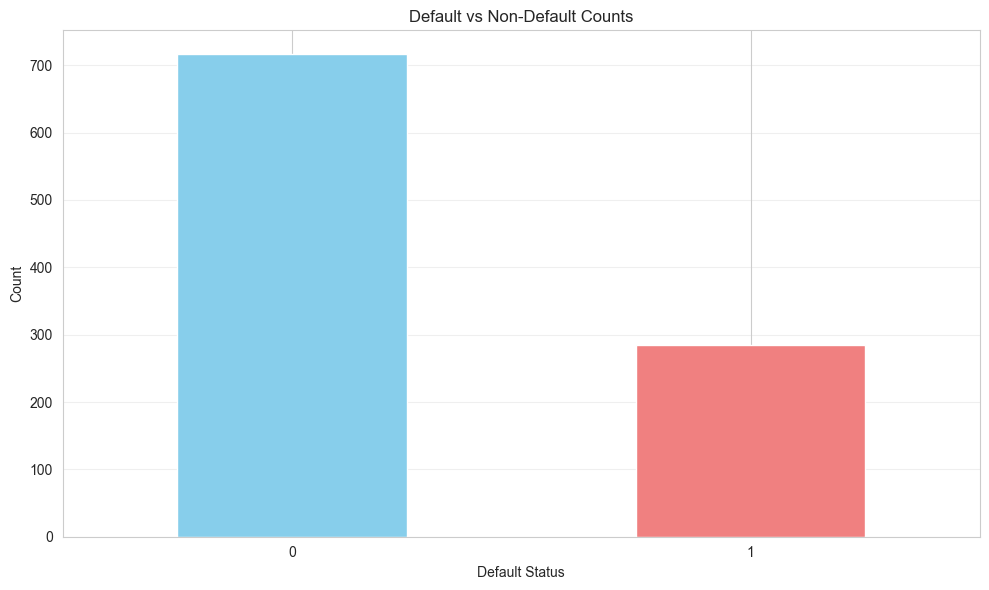

In [58]:
# Plot class distribution   
default_counts.plot(kind='bar', figsize=(10, 6), color=['skyblue', 'lightcoral'])
plt.title('Default vs Non-Default Counts')
plt.xlabel('Default Status')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [59]:
# Statistical summary of numerical columns
print("Statistical Summary of Numerical Columns:")
print(df.describe())

Statistical Summary of Numerical Columns:
              INCOME       SAVINGS          DEBT  R_SAVINGS_INCOME  \
count    1000.000000  1.000000e+03  1.000000e+03       1000.000000   
mean   121610.019000  4.131896e+05  7.907180e+05          4.063477   
std    113716.699591  4.429160e+05  9.817904e+05          3.968097   
min         0.000000  0.000000e+00  0.000000e+00          0.000000   
25%     30450.250000  5.971975e+04  5.396675e+04          1.000000   
50%     85090.000000  2.738505e+05  3.950955e+05          2.545450   
75%    181217.500000  6.222600e+05  1.193230e+06          6.307100   
max    662094.000000  2.911863e+06  5.968620e+06         16.111200   

       R_DEBT_INCOME  R_DEBT_SAVINGS  T_CLOTHING_12  T_CLOTHING_6  \
count    1000.000000     1000.000000    1000.000000   1000.000000   
mean        6.068449        5.867252    6822.401000   3466.320000   
std         5.847878       16.788356    7486.225932   5118.942977   
min         0.000000        0.000000       0.000000

In [60]:
# Data types overview
print("\nData Types Overview:")
print(df.dtypes.value_counts())


Data Types Overview:
float64    51
int64      34
object      2
Name: count, dtype: int64


In [61]:
# Identify string/object type columns
string_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"String/Object Columns: {string_cols}")
print(f"\nTotal: {len(string_cols)} string columns")

# Show sample values from each string column
for col in string_cols:
    print(f"\n{col}:")
    print(df[col].head(3).tolist())

String/Object Columns: ['CUST_ID', 'CAT_GAMBLING']

Total: 2 string columns

CUST_ID:
['C02COQEVYU', 'C02OZKC0ZF', 'C03FHP2D0A']

CAT_GAMBLING:
['High', 'No', 'High']


In [62]:
# Convert 'CAT_GAMBLING' to categorical type
df['CAT_GAMBLING'] = df['CAT_GAMBLING'].astype('category')

In [63]:
# Categorical columns analysis
categorical_cols = df.select_dtypes(include=['object']).columns
print(f"\nCategorical Columns: {categorical_cols.tolist()}")

for col in categorical_cols:
    print(f"\n{col} - Unique values: {df[col].nunique()}")
    print(df[col].value_counts().head(10))


Categorical Columns: ['CUST_ID']

CUST_ID - Unique values: 1000
CUST_ID
CZZV5B3SAL    1
C02COQEVYU    1
C02OZKC0ZF    1
C03FHP2D0A    1
C03PVPPHOY    1
C04J69MUX0    1
C04Q46QKOG    1
C069MLDS7X    1
CZJCTPQINE    1
CZI9GV5HZX    1
Name: count, dtype: int64


In [64]:
# Outlier detection using IQR method
numerical_cols = df.select_dtypes(include=[np.number]).columns
print("\nOutlier Detection (IQR Method):")
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))).sum()
    print(f"{col}: {outliers} outliers")


Outlier Detection (IQR Method):
INCOME: 25 outliers
SAVINGS: 28 outliers
DEBT: 44 outliers
R_SAVINGS_INCOME: 21 outliers
R_DEBT_INCOME: 35 outliers
R_DEBT_SAVINGS: 104 outliers
T_CLOTHING_12: 36 outliers
T_CLOTHING_6: 79 outliers
R_CLOTHING: 0 outliers
R_CLOTHING_INCOME: 53 outliers
R_CLOTHING_SAVINGS: 90 outliers
R_CLOTHING_DEBT: 103 outliers
T_EDUCATION_12: 67 outliers
T_EDUCATION_6: 67 outliers
R_EDUCATION: 11 outliers
R_EDUCATION_INCOME: 109 outliers
R_EDUCATION_SAVINGS: 141 outliers
R_EDUCATION_DEBT: 93 outliers
T_ENTERTAINMENT_12: 8 outliers
T_ENTERTAINMENT_6: 25 outliers
R_ENTERTAINMENT: 14 outliers
R_ENTERTAINMENT_INCOME: 50 outliers
R_ENTERTAINMENT_SAVINGS: 121 outliers
R_ENTERTAINMENT_DEBT: 112 outliers
T_FINES_12: 71 outliers
T_FINES_6: 48 outliers
R_FINES: 1 outliers
R_FINES_INCOME: 99 outliers
R_FINES_SAVINGS: 76 outliers
R_FINES_DEBT: 97 outliers
T_GAMBLING_12: 184 outliers
T_GAMBLING_6: 184 outliers
R_GAMBLING: 16 outliers
R_GAMBLING_INCOME: 160 outliers
R_GAMBLING_SAVI

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

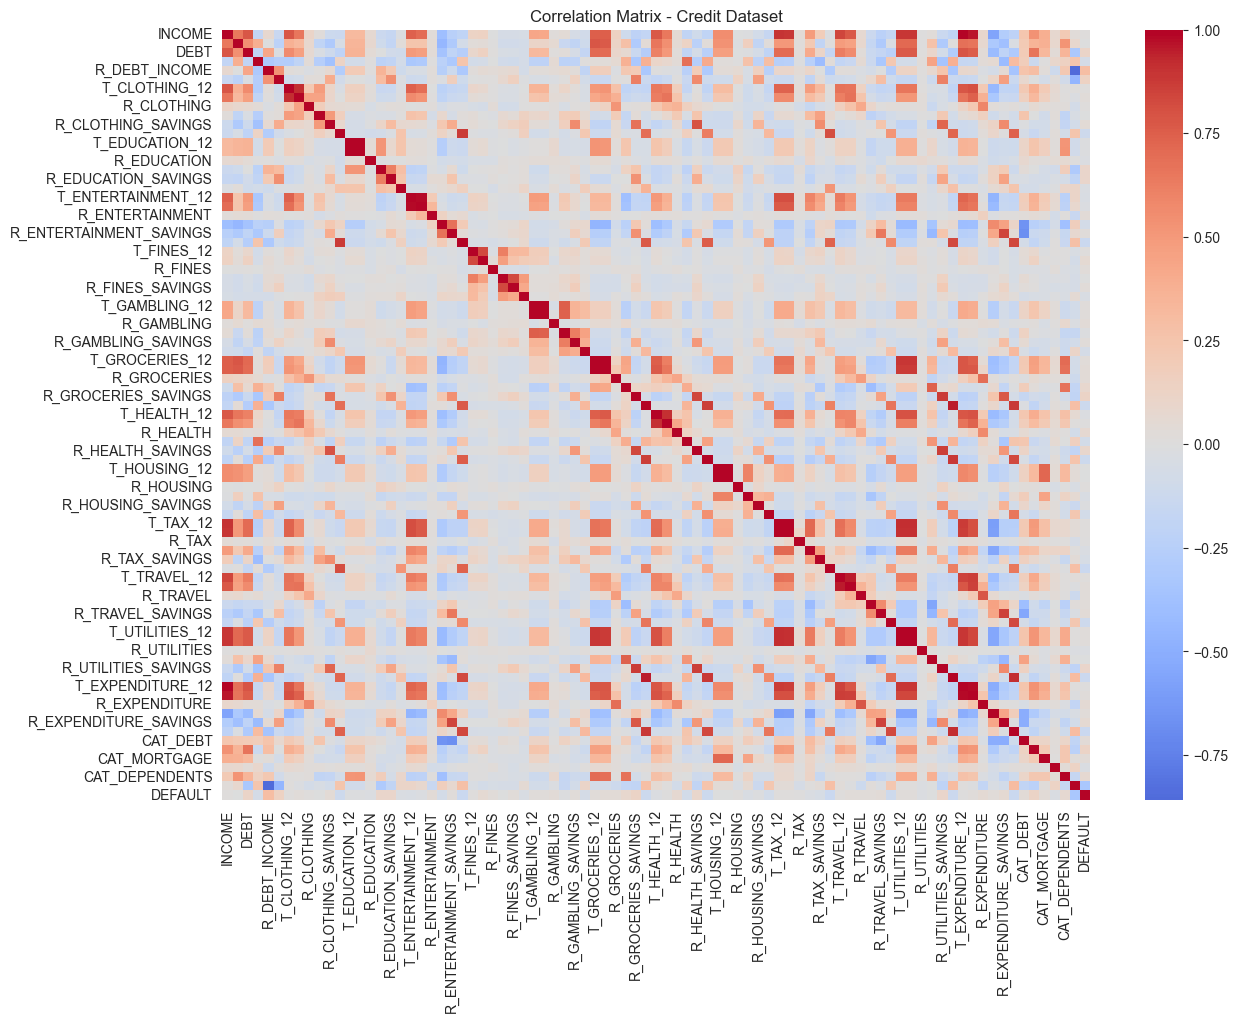

In [65]:
# Correlation analysis for credit dataset
numerical_cols_credit = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(14, 10))
sns.heatmap(df[numerical_cols_credit].corr(), cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Matrix - Credit Dataset')
plt.tight_layout

Pearson correlation analysis revealed near-perfect correlations between several numerical features, particularly between 6- and 12-month aggregated variables. Despite this redundancy, these features were intentionally retained in the feature set. Keeping highly correlated features allows the analysis to illustrate how SHAP explanations distribute importance across correlated inputs and highlights the dependency of post hoc explainability on feature correlation and representation. This supports the assessment of SHAP as a transparency tool that reflects model behaviour in the presence of correlated features rather than enforcing a unique or model-independent explanation.

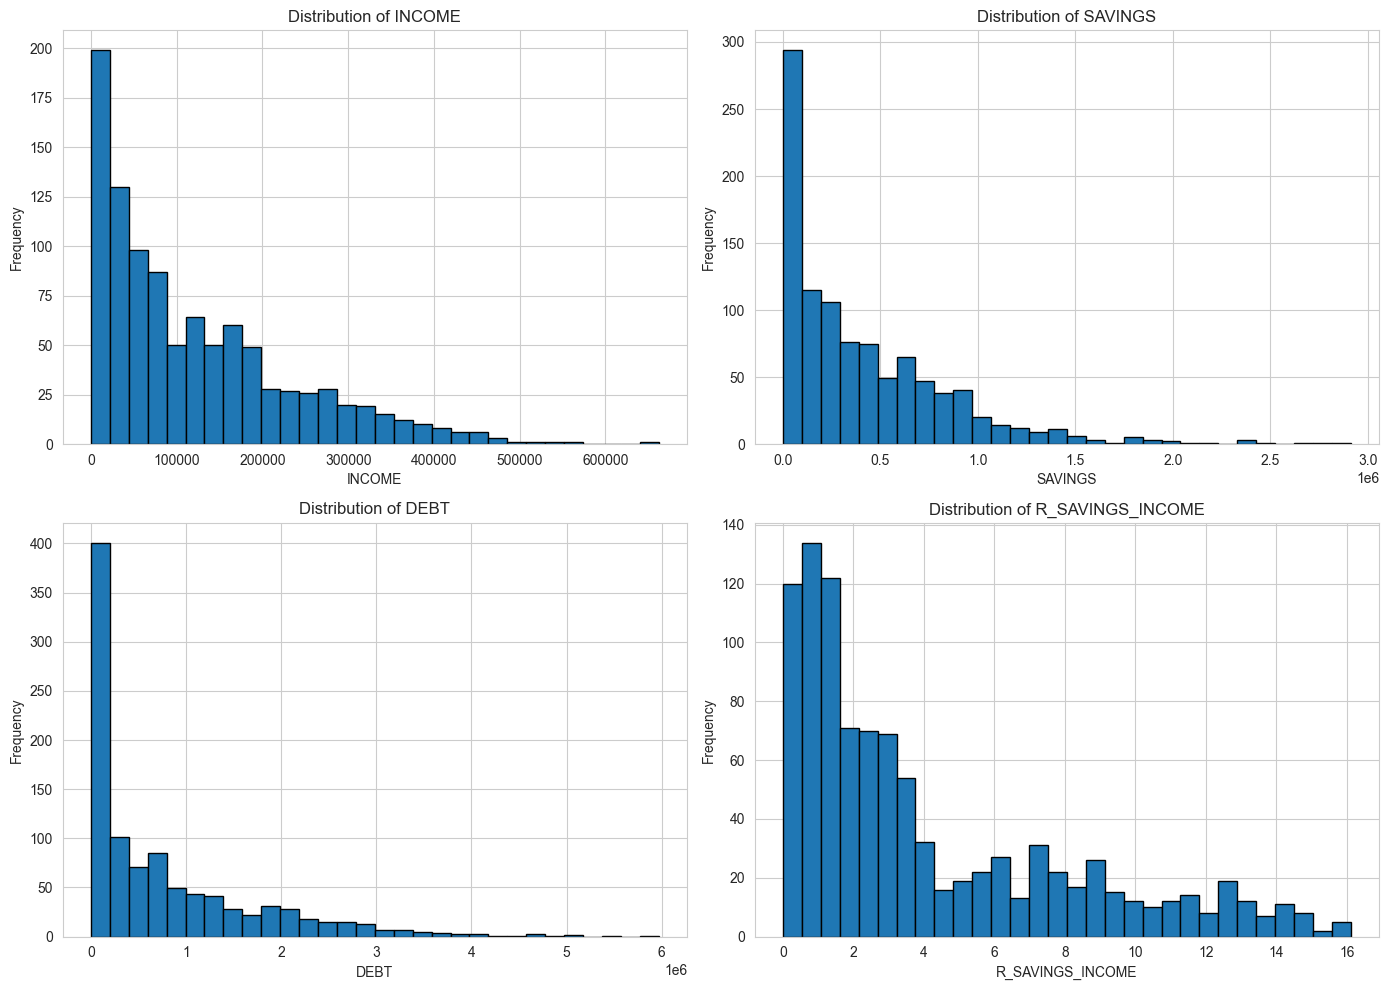

In [66]:
# Distribution plots for numerical features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()
for idx, col in enumerate(numerical_cols[:4]):
    axes[idx].hist(df[col].dropna(), bins=30, edgecolor='black')
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

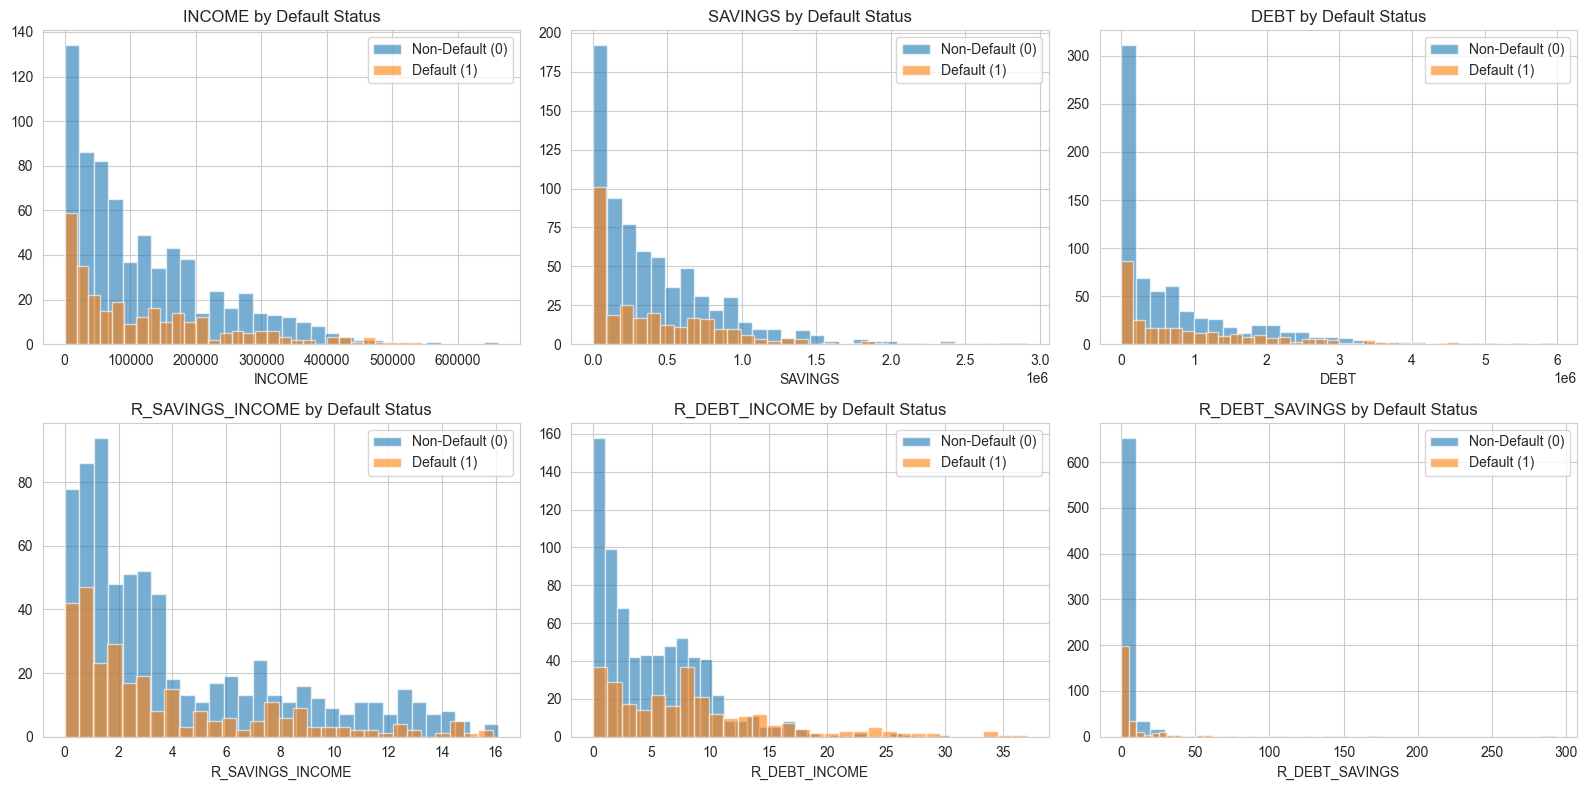

In [67]:
# Numerical feature distributions by default status (explicit legend for colors)
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.ravel()
sample_numeric = numerical_cols_credit[:6]

for idx, col in enumerate(sample_numeric):
    non_def = df.loc[df['DEFAULT'] == 0, col].dropna()
    is_def = df.loc[df['DEFAULT'] == 1, col].dropna()
    axes[idx].hist(non_def, bins=30, alpha=0.6, color='tab:blue', label='Non-Default (0)')
    axes[idx].hist(is_def, bins=30, alpha=0.6, color='tab:orange', label='Default (1)')
    axes[idx].set_title(f'{col} by Default Status')
    axes[idx].set_xlabel(col)
    axes[idx].legend()

plt.tight_layout()
plt.show()

Data preparation

In [68]:
# Drop CUST_ID and handle missing values
df_credit = df.drop(columns=['CUST_ID'])

# Check missing values
print("Missing values before handling:")
print(df_credit.isnull().sum().sum())

# Drop rows with missing values
df_credit = df_credit.dropna()

print(f"\nDataset shape after cleaning: {df_credit.shape}")
print(f"Rows removed: {len(df) - len(df_credit)}")

# Verify target variable distribution
print(f"\nTarget variable (DEFAULT) distribution:")
print(df_credit['DEFAULT'].value_counts())

Missing values before handling:
0

Dataset shape after cleaning: (1000, 86)
Rows removed: 0

Target variable (DEFAULT) distribution:
DEFAULT
0    716
1    284
Name: count, dtype: int64


In [69]:
# Separate features and target variable
X = df_credit.drop(columns=['DEFAULT'])
y = df_credit['DEFAULT']

In [70]:
# Split data into training and testing sets with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [71]:
# Check class distribution in train and test sets
print("Train distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest distribution:")
print(y_test.value_counts(normalize=True))


Train distribution:
DEFAULT
0    0.71625
1    0.28375
Name: proportion, dtype: float64

Test distribution:
DEFAULT
0    0.715
1    0.285
Name: proportion, dtype: float64


### 9.2 Model Training & Evaluation 

In [72]:
# Identify categorical features
cat_features = X_train.select_dtypes(include='category').columns.tolist()

cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=False
)

cat_model.fit(
    X_train,
    y_train,
    cat_features=cat_features
)

# Evaluation
cat_pred = cat_model.predict_proba(X_test)[:, 1]
cat_auc = roc_auc_score(y_test, cat_pred)

print(cat_auc)  


0.6011532327321801


In [73]:
# One-hot encode categorical variables for XGBoost
X_train_xgb = pd.get_dummies(X_train, drop_first=True)
X_test_xgb  = pd.get_dummies(X_test, drop_first=True)

# Align columns (important!)
X_train_xgb, X_test_xgb = X_train_xgb.align(X_test_xgb, join='left', axis=1, fill_value=0)


In [74]:
# Train XGBoost model
xgb_model.fit(X_train_xgb, y_train)

# Evaluate XGBoost model
xgb_pred = xgb_model.predict_proba(X_test_xgb)[:, 1]
xgb_auc = roc_auc_score(y_test, xgb_pred)

print(xgb_auc)


c:\Users\justu\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [08:59:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


0.6265488897067845


In [75]:
# Reuse one-hot encoded data
X_train_rf = X_train_xgb
X_test_rf  = X_test_xgb


In [76]:
# Train Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_rf, y_train)


RandomForestClassifier(n_estimators=500, n_jobs=-1, random_state=42)

In [77]:
rf_pred = rf_model.predict_proba(X_test_rf)[:, 1]
rf_auc = roc_auc_score(y_test, rf_pred)

# Evaluate Random Forest model
print( 
rf_auc)


0.6300453932032879


In [78]:
# Function to evaluate model performance
def evaluate_model(y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)

    # Use sklearn metrics to compute evaluation metrics
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_proba)
    }


In [79]:
# Evaluate Catboost Forest model
cat_proba = cat_model.predict_proba(X_test)[:, 1]
cat_metrics = evaluate_model(y_test, cat_proba)

cat_metrics


{'Accuracy': 0.725,
 'Precision': 0.5416666666666666,
 'Recall': 0.22807017543859648,
 'F1': 0.32098765432098764,
 'ROC_AUC': np.float64(0.6011532327321801)}

In [80]:
# Evaluate XGBosot Forest model
xgb_proba = xgb_model.predict_proba(X_test_xgb)[:, 1]
xgb_metrics = evaluate_model(y_test, xgb_proba)

xgb_metrics


{'Accuracy': 0.72,
 'Precision': 0.5151515151515151,
 'Recall': 0.2982456140350877,
 'F1': 0.37777777777777777,
 'ROC_AUC': np.float64(0.6265488897067845)}

In [81]:
# Evaluate Random Forest model
rf_proba = rf_model.predict_proba(X_test_rf)[:, 1]
rf_metrics = evaluate_model(y_test, rf_proba)

rf_metrics


{'Accuracy': 0.72,
 'Precision': 0.5294117647058824,
 'Recall': 0.15789473684210525,
 'F1': 0.24324324324324326,
 'ROC_AUC': np.float64(0.6300453932032879)}

In [82]:
# Compile results into a DataFrame
results_df = pd.DataFrame.from_dict(
    {
        "CatBoost": cat_metrics,
        "XGBoost": xgb_metrics,
        "RandomForest": rf_metrics
    },
    orient="index"
)

results_df


,Accuracy,Precision,Recall,F1,ROC_AUC
CatBoost,0.725,0.541667,0.228070,0.320988,0.601153
XGBoost,0.720,0.515152,0.298246,0.377778,0.626549
RandomForest,0.720,0.529412,0.157895,0.243243,0.630045


All models achieved moderate predictive performance, reflecting the inherent difficulty of the prediction task. The objective of this study was not to optimise model performance, but to analyse model behaviour and the dependency of explainability methods on feature representation and correlation. Within this context, XGBoost consistently outperformed CatBoost and Random Forest across ROC-AUC, F1-score, precision, and recall. Accuracy values were similar across models and primarily reflect class imbalance rather than discriminative power. Given its superior and stable performance, XGBoost was selected for subsequent explainability analysis.

### 9.3 Explainability and Multicollinearity Analysis

For the second dataset, SHAP and LIME were applied to analyse feature contributions and local prediction behaviour. Compared to the first model, the feature influence structure is more complex, reflecting differences in the underlying data distribution and feature interactions.


In addition to explainability, the effect of multicollinearity between input features was examined. This analysis provided insight into how correlated features influence feature-attribution results, particularly in SHAP explanations where importance may be distributed across related variables.


In [83]:
# Get SHAP values for XGBoost model
explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test_xgb)

# Handle binary classification output
if isinstance(shap_values, list):
    shap_values = shap_values[1]  # positive class

shap_values = np.asarray(shap_values)


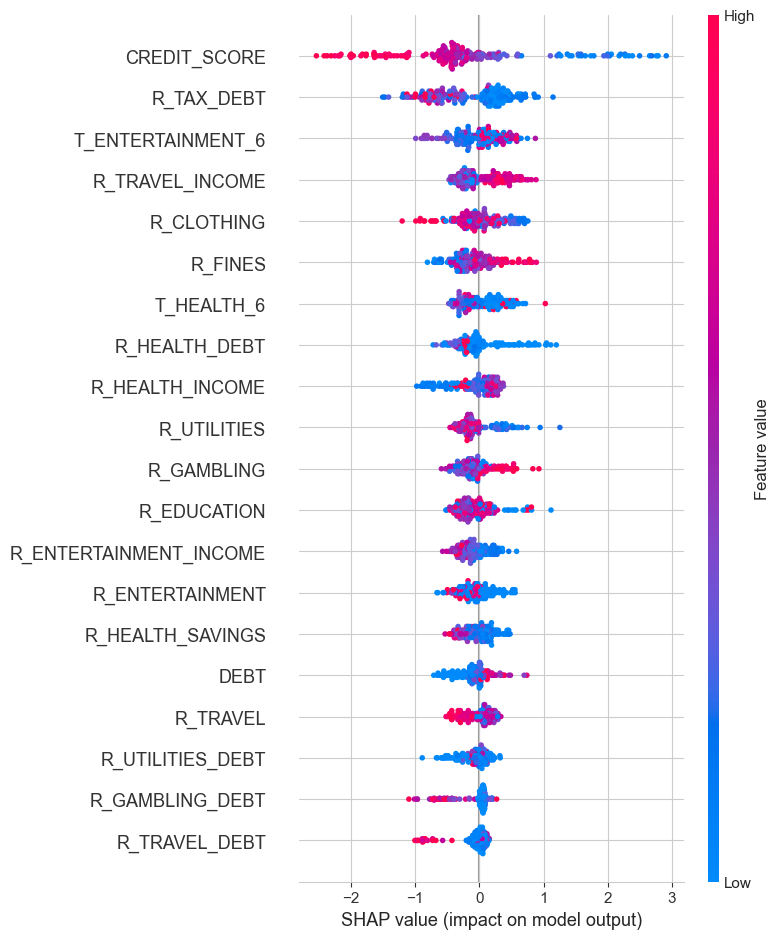

In [84]:
# Plot SHAP summary for 
shap.summary_plot(
    shap_values,
    X_test_xgb,
    show=False
)


In [85]:
# Check whether SHAP values shape matches test data
print(shap_values.shape)
print(X_test_xgb.shape)


(200, 86)
(200, 86)


In [86]:
# Numerical features only
X_num = X_test_xgb.astype(float)

# Pearson correlation matrix
corr_matrix = X_num.corr(method="pearson")


In [87]:
# Check correlation pairs
mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)

corr_pairs = (
    corr_matrix.abs()
    .where(mask)
    .stack()
    .sort_values(ascending=False)
)

corr_pairs.head(10)

T_HOUSING_12        T_HOUSING_6          1.000000
T_EDUCATION_12      T_EDUCATION_6        0.999994
T_UTILITIES_12      T_UTILITIES_6        0.999992
T_GAMBLING_12       T_GAMBLING_6         0.997938
T_TAX_12            T_TAX_6              0.997273
T_GROCERIES_12      T_GROCERIES_6        0.993967
INCOME              T_EXPENDITURE_12     0.987862
T_ENTERTAINMENT_12  T_ENTERTAINMENT_6    0.981313
T_EXPENDITURE_12    T_EXPENDITURE_6      0.976264
R_GROCERIES_DEBT    R_UTILITIES_DEBT     0.966266
dtype: float64

T_HOUSING_12 and T_HOUSING_6 show perfect positive correlation.

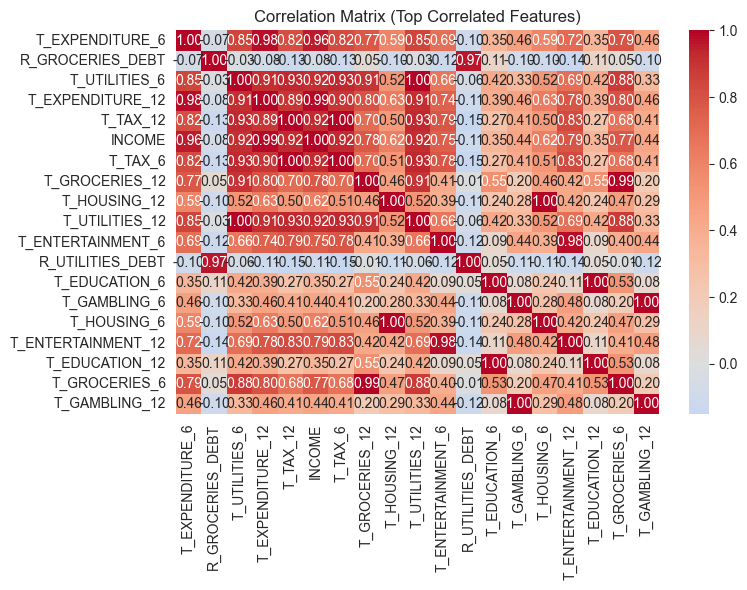

In [88]:
# Plot correlation heatmap for top correlated features
top_features = list(
    set([f for pair in corr_pairs.head(10).index for f in pair])
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix.loc[top_features, top_features],
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f"
)
plt.title("Correlation Matrix (Top Correlated Features)")
plt.tight_layout()
plt.show()


In [89]:
# Check column names
X.columns

Index(['INCOME', 'SAVINGS', 'DEBT', 'R_SAVINGS_INCOME', 'R_DEBT_INCOME',
       'R_DEBT_SAVINGS', 'T_CLOTHING_12', 'T_CLOTHING_6', 'R_CLOTHING',
       'R_CLOTHING_INCOME', 'R_CLOTHING_SAVINGS', 'R_CLOTHING_DEBT',
       'T_EDUCATION_12', 'T_EDUCATION_6', 'R_EDUCATION', 'R_EDUCATION_INCOME',
       'R_EDUCATION_SAVINGS', 'R_EDUCATION_DEBT', 'T_ENTERTAINMENT_12',
       'T_ENTERTAINMENT_6', 'R_ENTERTAINMENT', 'R_ENTERTAINMENT_INCOME',
       'R_ENTERTAINMENT_SAVINGS', 'R_ENTERTAINMENT_DEBT', 'T_FINES_12',
       'T_FINES_6', 'R_FINES', 'R_FINES_INCOME', 'R_FINES_SAVINGS',
       'R_FINES_DEBT', 'T_GAMBLING_12', 'T_GAMBLING_6', 'R_GAMBLING',
       'R_GAMBLING_INCOME', 'R_GAMBLING_SAVINGS', 'R_GAMBLING_DEBT',
       'T_GROCERIES_12', 'T_GROCERIES_6', 'R_GROCERIES', 'R_GROCERIES_INCOME',
       'R_GROCERIES_SAVINGS', 'R_GROCERIES_DEBT', 'T_HEALTH_12', 'T_HEALTH_6',
       'R_HEALTH', 'R_HEALTH_INCOME', 'R_HEALTH_SAVINGS', 'R_HEALTH_DEBT',
       'T_HOUSING_12', 'T_HOUSING_6', 'R_HOUSING',

T_ENTERTAINMENT_12 was excluded to evaluate the effect of multicollinearity.

c:\Users\justu\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [08:59:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


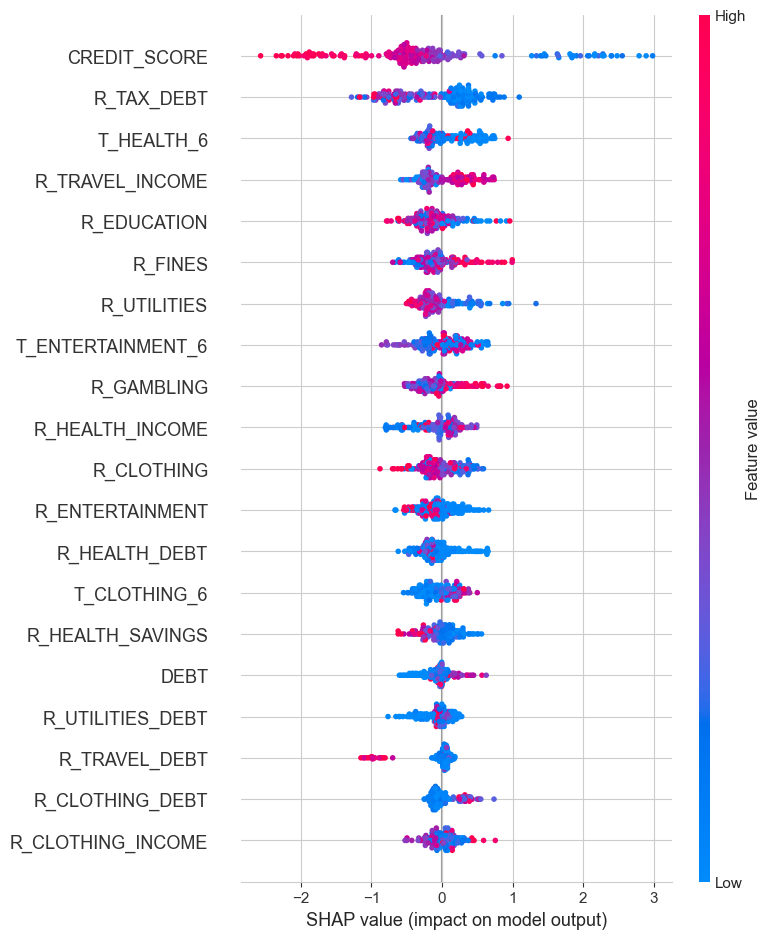

In [90]:
# Drop T_
f12 = 'T_ENTERTAINMENT_12'

# Drop from RESAMPLED training data
X_train_drop = X_train_xgb.drop(columns=[f12])
X_test_drop  = X_test_xgb.drop(columns=[f12])

xgb_model_drop = xgb.XGBClassifier(
    use_label_encoder=False,
    enable_categorical=True,
    eval_metric='aucpr',
    random_state=42
)

xgb_model_drop.fit(X_train_drop, y_train)

explainer_drop = shap.TreeExplainer(xgb_model_drop)
shap_values_drop = explainer_drop.shap_values(X_test_drop)

shap.summary_plot(shap_values_drop, X_test_drop)


In the full model, T_ENTERTAINMENT_6 appears among the most influential predictors in the SHAP summary plot. After removing the correlated variable T_ENTERTAINMENT_12, the SHAP importance of T_ENTERTAINMENT_6 decreases and the attribution is redistributed across other lifestyle-related expenditure features, including R_ENTERTAINMENT, R_CLOTHING, and travel-related income and debt ratios. This shift indicates that the high SHAP value of T_ENTERTAINMENT_6 in the full model was partly driven by shared information with T_ENTERTAINMENT_12, rather than a unique contribution. The observed instability of SHAP rankings under feature removal demonstrates the effect of multicollinearity on individual feature attributions.

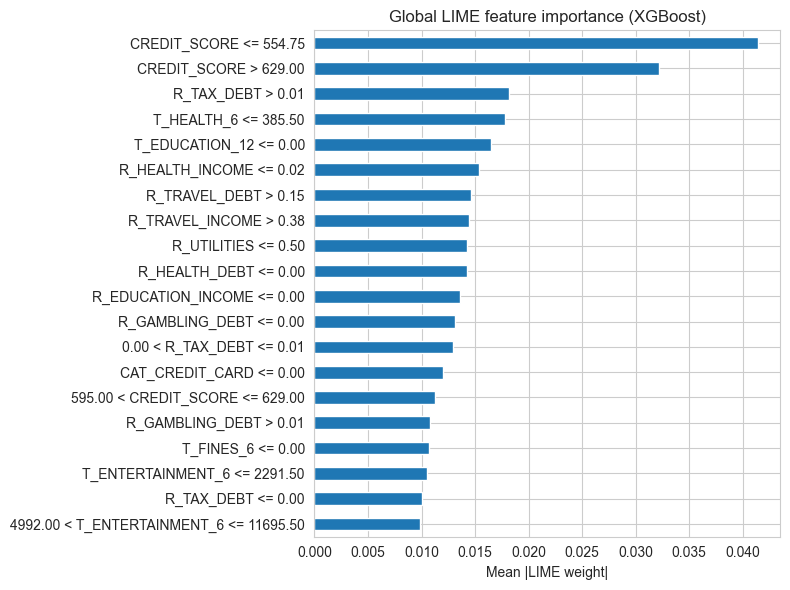

In [91]:
# Ensure train/test have identical columns in identical order
X_train_full, X_test_full = X_train_xgb.align(
    X_test_xgb, join="left", axis=1, fill_value=0
)

# Create LIME explainer using EXACT training data
lime_explainer = LimeTabularExplainer(
    training_data=X_train_full.values,
    feature_names=X_train_full.columns.tolist(),
    class_names=["No", "Yes"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

# Collect LIME weights for all test instances
lime_weights = []

for i in range(X_test_full.shape[0]):
    exp = lime_explainer.explain_instance(
        data_row=X_test_full.iloc[i].values,
        predict_fn=lambda x: xgb_model.predict_proba(
            pd.DataFrame(x, columns=X_train_full.columns)
        ),
        num_features=len(X_train_full.columns)
    )
    lime_weights.append(dict(exp.as_list()))

# Aggregate to global LIME importance
lime_df = pd.DataFrame(lime_weights).fillna(0)

lime_global = (
    lime_df
    .abs()
    .mean()
    .sort_values(ascending=False)
)

# Plot global LIME importance
plt.figure(figsize=(8, 6))
lime_global.head(20).plot(kind="barh")
plt.gca().invert_yaxis()
plt.xlabel("Mean |LIME weight|")
plt.title("Global LIME feature importance (XGBoost)")
plt.tight_layout()
plt.show()

#### 9.4 Results - Model 2

SHAP analysis indicates that Model 2 predictions are primarily driven by credit score and a set of correlated debt- and expenditure-related variables. When the correlated feature T_ENTERTAINMENT_12 was removed, the SHAP importance of T_ENTERTAINMENT_6 decreased, with attribution redistributed across other entertainment- and lifestyle-related variables. This redistribution occurred without meaningful changes in model performance, suggesting that these features share predictive information rather than contributing uniquely.

Global LIME explanations, obtained by aggregating local explanations across observations, identify the same core groups of influential predictors, particularly credit score and debt-related ratios. LIME represents these influences through local, threshold-based decision rules and shows that entertainment-related variables contribute via multiple moderate-weight rules across different regions of the feature space. Importantly, LIME explanations remain relatively stable under feature removal.

#### 9.5 Conclusion – Model 2

Taken together, these results show that Model 2 relies on a limited number of correlated financial and lifestyle feature groups, whose effects are expressed in a non-linear, threshold-based manner consistent with tree-based models. The instability of SHAP attributions under feature removal reflects the presence of multicollinearity and highlights the non-identifiability of individual feature effects in this setting.

While SHAP is effective in revealing attribution instability caused by correlated inputs, LIME provides a complementary perspective by confirming that the same feature groups consistently influence model predictions. Because LIME does not attempt to uniquely assign importance among correlated features, its explanations remain more stable under feature removal, supporting interpretation at the level of feature groups rather than individual predictors.

Consequently, these findings emphasise that explainability outcomes depend strongly on feature correlations and modelling choices. In the presence of multicollinearity, explainable AI methods should be used to support group-level interpretation and diagnostic analysis, rather than to infer precise causal importance of individual variables.


---
## 10. Overall Conclusion

This project demonstrates how explainable AI methods can be used to analyse and compare the decision-making behaviour of machine-learning models in a financial context. While Model 1 achieves stronger predictive performance, Model 2 exhibits lower performance but more distributed and stable explanatory behaviour. Explainability analysis therefore reveals fundamentally different learning strategies and trade-offs that are not apparent from performance metrics alone.

Model 1 relies strongly on high-cardinality identifiers, resulting in sharp performance degradation under feature ablation and enabling clearer identification of individual drivers at the cost of reduced robustness. In contrast, Model 2 distributes predictive importance across correlated financial and lifestyle feature groups. These findings highlight that model choice directly influences both predictive performance and the reliability of post-hoc explanations.

The combined use of SHAP and LIME provides complementary insights into model behaviour. SHAP is effective for diagnosing feature reliance and attribution instability, particularly under perturbation, while LIME supports more stable, group-level interpretation in the presence of correlated inputs. However, the results also confirm that post-hoc explainability remains inherently model-dependent and sensitive to feature representation, limiting its suitability as a standalone mechanism for regulatory or compliance purposes.

In light of the EU AI Act’s requirements for transparency, accountability, and human oversight in high-risk AI systems, these findings emphasise that explainable AI should be embedded within a broader governance framework rather than treated as a purely technical solution (European Union, 2024). For real-world deployment in regulated financial environments, practitioners should align model choice, explainability techniques, and interpretation level with the intended use case, balancing predictive performance, robustness of explanations, and regulatory obligations.

Finally, the findings of this notebook directly operationalise the research gaps identified in the one-pager. In particular, the observed sensitivity of post-hoc explanations to feature perturbation, model architecture, and correlated inputs highlights ongoing challenges related to explanation stability, reproducibility, and behavioural fidelity. Future research should therefore focus on systematic robustness evaluation of explainability techniques, investigation of explanation behaviour under dataset shift and temporal drift, and comparative analysis of post-hoc methods versus inherently interpretable model architectures. Addressing these challenges is essential for advancing trustworthy, regulator-ready explainability frameworks for high-risk financial machine-learning applications.


---
## 11. Managerial Implications

The results of this analysis demonstrate that explainable AI methods can enhance transparency and understanding in financial machine-learning models, but that their outputs must be interpreted with care. SHAP provides detailed insights into how individual features contribute to model predictions, making it a valuable tool for technical validation, model diagnostics, and the detection of over-reliance on specific variables. However, in the presence of correlated predictors, feature-level attributions may be unstable, indicating that managers and analysts should avoid interpreting SHAP outputs as unique or causal explanations of individual feature effects.

The complementary use of LIME shows that local, rule-based explanations can help confirm which groups of variables consistently influence model decisions, even when individual feature attributions vary. Together, these findings suggest that managers should not rely on a single explainability technique, but instead adopt a multi-method approach that aligns explainability tools with their specific governance, validation, or communication objectives. Explainable AI should therefore be embedded within broader model risk management, validation, and review processes, rather than treated as a standalone compliance solution.

### Real-World Deployment Context

This notebook represents the analytical core of an explainable
decision-support system for the financial sector.

In a real-world setting, this pipeline would be embedded in a
human-in-the-loop workflow, where:
- models are trained offline on historical data,
- predictions and post-hoc explanations (e.g., SHAP/LIME) are generated
  periodically,
- Models are checked periodically with out of distribution data,
- outputs are reviewed by analysts, auditors, or compliance officers,
- final decisions remain human-led to ensure accountability and
  regulatory compliance.

Real-time automation and fully autonomous decision-making are
intentionally out of scope, as explainability, transparency, and
governance are prioritized over automation in regulated financial
environments.

### Proposed Deployment Architecture

In a real-world financial environment, the proposed solution would be deployed as a modular pipeline:

1. **ETL Layer**  
   - Raw transactional and customer data are ingested daily.
   - Data validation rules detect missing values, outliers, and inconsistencies.
   - Feature engineering is applied consistently across training and inference.

2. **Model Layer**  
   - A supervised ML model generates risk predictions.
   - Model performance is continuously monitored.

3. **Explainability Layer**  
   - SHAP is used for global and local explanations.
   - LIME supports case-level validation by analysts.

4. **Decision Support & Monitoring**  
   - Explanations are presented in analyst dashboards.
   - Drift and explanation instability are flagged for review.
   - The regulation periodically checks predictions and explanations. Therefore, explainability should be clear



---
## 12. Reflection and Limitations

Although explainable AI techniques such as SHAP and LIME provide valuable insights into model behaviour, they remain post-hoc methods and do not offer causal explanations. The experiments in this notebook show that explanation outputs are influenced by modelling choices, feature representation, and data dependencies such as multicollinearity, which limits the interpretability of individual feature effects.

Additionally, global explanations derived from aggregating local methods, such as LIME, depend on aggregation choices and may obscure instance-level variability. As such, explainability should be viewed as a complementary analytical tool that enhances transparency and understanding, rather than a complete solution to issues of fairness, accountability, or regulatory compliance in financial machine learning.

Furthermore, no widely accepted standardized validation metrics for explainable AI currently exist, which complicates objective assessment of explanation quality. Therefore, interpretation of these Post-Hoc models should be done with care and expert review. As shown by the experiments, results are not always correct under real-life circumstances.


# 13. References
berkanoztas. (2023). Synthetic transaction monitoring dataset (AML) [Data set]. Kaggle. https://www.kaggle.com/datasets/berkanoztas/synthetic-transaction-monitoring-dataset-aml

conorslily. (2023). Credit score [Data set]. Kaggle. https://www.kaggle.com/datasets/conorslily/credit-score

European Union. (2024). Regulation (EU) 2024/1689 of the European Parliament and of the Council of 12 July 2024 on artificial intelligence (EU AI Act). Official Journal of the European Union.

Lundberg, S. M., & Lee, S.-I. (2017). A unified approach to interpreting model predictions. In Advances in neural information processing systems (NeurIPS) (vol. 30). https://proceedings.neurips.cc/paper_files/paper/2017/hash/8a20a8621978632d76c43dfd28b67767-Abstract.html

Ribeiro, M. T., Singh, S., & Guestrin, C. (2016). "Why should I trust you?": Explaining the predictions of any classifier. In Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining (pp. 1135–1144). https://doi.org/10.1145/2939672.2939778


Studer, S., Bui, T. B., Drescher, C., Hanuschkin, A., Winkler, L., Peters, S., & Müller, K.-
R. (2021). Towards CRISP-ML(Q): A machine learning process model with quality
assurance methodology. Machine Learning and 